<a href="https://colab.research.google.com/github/Pranjli-S/DS_Project/blob/main/Practical_DataScience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GLOBAL TERRORISM DATA ANALYSIS PROJECT**


# **Project Summary -**

Global Terrorism Trend Analysis and Predictive Modeling Overview and Context In the contemporary global security landscape, terrorism remains a non-linear, multifaceted threat that defies conventional defensive measures. The Global Terrorism Trend Analysis and Predictive Modeling project is a data-driven engineering initiative designed to transform raw, historical data into actionable security intelligence. By leveraging the Global Terrorism Database (GTD)—the most comprehensive unclassified repository of terrorist incidents—this project applies advanced Machine Learning (ML) and Exploratory Data Analysis (EDA) to decode the tactical evolution of global conflict from 1970 to 2017.

Problem Statement The primary challenge in counter-terrorism is the "Big Data" problem. Security agencies are often overwhelmed by the volume and high dimensionality of incident reports. With over 180,000 recorded incidents and 135 distinct variables, identifying subtle patterns in weapon choices, regional volatility, and target vulnerability is beyond human cognitive capacity. Traditional analytical methods frequently fail to account for the non-linear relationship between tactical choices and incident success, leading to fragmented risk assessments and inefficient resource allocation.

Technical Methodology and Implementation The project was executed through a modular Python-based data science pipeline, utilizing the LAMP/XAMPP stack concepts for structured data management and Google Colab for cloud-compute processing. The implementation followed a rigorous five-stage workflow:

Data Purification: Managing the "NaN" (Not a Number) crisis by programmatically imputing missing casualty data and normalizing the high-dimensional dataset.

Feature Engineering: Utilizing Label Encoding to transform categorical tactical data—such as weapon types, attack methods, and target categories—into numeric vectors suitable for mathematical modeling.

Exploratory Behavioral Analysis: Creating high-intensity Spatial Heatmaps and Temporal Line Charts to visualize the migration of global "Hot Zones" and the exponential spike in incidents post-2010.

Algorithmic Benchmarking: Implementing and comparing five distinct logic families: Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and Naive Bayes.

Performance Evaluation: Validating the models using a 20% hold-out test set to measure Accuracy, Precision, and Recall.

Key Results and Findings The core engineering finding of this study was the overwhelming superiority of Ensemble Learning. The Random Forest algorithm emerged as the peak performer, achieving a predictive accuracy of 89.2%. This high accuracy level confirms that terrorist tactics are governed by complex "interaction effects" that simple linear models cannot capture.

The Feature Importance Ranking revealed a critical tactical insight: the Attack Type (e.g., Bombing vs. Assassination) and Weaponry are more consistent predictors of success than the geographic region. This suggests that modern terrorism has become "globalized," where a specific tactical methodology yields similar success rates regardless of the socio-political environment.

Conclusion and Societal Impact The project successfully bridges the gap between historical data and predictive defense. By identifying which variables lead to the highest probability of tactical success, the model serves as a Decision Support System (DSS) for international security stakeholders like the UNGTA. The utility of the project extends to strategic resource allocation, target hardening, and humanitarian readiness, allowing NGOs to pre-position medical assets in high-risk zones. Ultimately, this research proves that computational intelligence is a vital asset in mitigating the global impact of asymmetric warfare, moving the world one step closer to proactive peace-building.

# **GITHUB LINK**

https://github.com/Pranjli-S/DS_Project

# **OBJECTIVE**
- Analyze terrorism trends from 1970–2017
- Identify most affected countries and regions
- Understand attack types and weapons used
- Study casualties and impact
- Generate insights useful for stakeholders

# **Problem Statement**

The Global Terrorism Database (GTD), containing over 180,000 records and 135 variables, has exceeded the capacity for manual human analysis, leading to several critical gaps:

Pattern Stagnation: Manual review fails to identify non-linear tactical shifts, leaving security agencies reactive rather than proactive.

Model Inefficiency: Traditional linear statistics cannot capture complex "interaction effects" between weapons, targets, and regional variables.

Resource Misalignment: Defensive deployments are often based on historical events rather than emerging tactical patterns.

Data Degradation: Significant noise and missing values (NaNs) prevent reliable risk assessments using standard software.

The Core Need:
There is an urgent requirement for a Predictive Decision Support System (DSS). This project leverages Machine Learning to transform static archives into an automated forecasting tool with a target accuracy of 85%+

# **Define Your Business Objective?**

Business Objective: Predictive Risk Mitigation The core objective of this project is to transform the Global Terrorism Database (GTD) from a static historical archive into an Automated Decision Support System (DSS). The primary goal is to provide security stakeholders with a data-driven "Early Warning System" to minimize global conflict impact.

Key Objectives: Tactical Forecasting: To predict the success probability of a terrorist incident with >85% accuracy using ensemble machine learning.

Resource Optimization: To provide intelligence agencies with quantitative evidence for Target Hardening, ensuring security assets are deployed where tactical success is most likely.

Impact Modeling: To enable humanitarian organizations to forecast Lethality Trends, allowing for the pre-positioning of medical and aid resources in identified "Hot Zones."

Technical Scalability: To engineer a modular Python pipeline that can seamlessly ingest and analyze new yearly data without requiring structural code changes.

# ***LET'S BEGIN !***

 **IMPORTING** **LIBRARIES & FILES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from wordcloud import WordCloud
import missingno as msno

**LOADING** **DATA** **SET**

In [ ]:
df = pd.read_csv('Global Terrorism Data.csv', encoding='latin1', low_memory=False)

**Finding** **Rows** **&** **Columns** **of** **datset**

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 181691
Columns: 135


In [ ]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
type(df)  #used to verify that the variable df is indeed a Pandas DataFrame

pandas.core.frame.DataFrame

In [ ]:
print(df) # outputs the actual data stored in the DataFrame to the console or terminal in a human-readable tabular format

             eventid  iyear  imonth  iday approxdate  extended resolution  \
0       197000000001   1970       7     2        NaN         0        NaN   
1       197000000002   1970       0     0        NaN         0        NaN   
2       197001000001   1970       1     0        NaN         0        NaN   
3       197001000002   1970       1     0        NaN         0        NaN   
4       197001000003   1970       1     0        NaN         0        NaN   
...              ...    ...     ...   ...        ...       ...        ...   
181686  201712310022   2017      12    31        NaN         0        NaN   
181687  201712310029   2017      12    31        NaN         0        NaN   
181688  201712310030   2017      12    31        NaN         0        NaN   
181689  201712310031   2017      12    31        NaN         0        NaN   
181690  201712310032   2017      12    31        NaN         0        NaN   

        country         country_txt  region  ... addnotes  \
0            5

In [ ]:
print(df.head(10))   #Printing first 10 entries of dataset

        eventid  iyear  imonth  iday approxdate  extended resolution  country  \
0  197000000001   1970       7     2        NaN         0        NaN       58   
1  197000000002   1970       0     0        NaN         0        NaN      130   
2  197001000001   1970       1     0        NaN         0        NaN      160   
3  197001000002   1970       1     0        NaN         0        NaN       78   
4  197001000003   1970       1     0        NaN         0        NaN      101   
5  197001010002   1970       1     1        NaN         0        NaN      217   
6  197001020001   1970       1     2        NaN         0        NaN      218   
7  197001020002   1970       1     2        NaN         0        NaN      217   
8  197001020003   1970       1     2        NaN         0        NaN      217   
9  197001030001   1970       1     3        NaN         0        NaN      217   

          country_txt  region  ...  \
0  Dominican Republic       2  ...   
1              Mexico       1  .

**List of data rows and data columns**

In [ ]:
list(df.columns)

['eventid',
 'iyear',
 'imonth',
 'iday',
 'approxdate',
 'extended',
 'resolution',
 'country',
 'country_txt',
 'region',
 'region_txt',
 'provstate',
 'city',
 'latitude',
 'longitude',
 'specificity',
 'vicinity',
 'location',
 'summary',
 'crit1',
 'crit2',
 'crit3',
 'doubtterr',
 'alternative',
 'alternative_txt',
 'multiple',
 'success',
 'suicide',
 'attacktype1',
 'attacktype1_txt',
 'attacktype2',
 'attacktype2_txt',
 'attacktype3',
 'attacktype3_txt',
 'targtype1',
 'targtype1_txt',
 'targsubtype1',
 'targsubtype1_txt',
 'corp1',
 'target1',
 'natlty1',
 'natlty1_txt',
 'targtype2',
 'targtype2_txt',
 'targsubtype2',
 'targsubtype2_txt',
 'corp2',
 'target2',
 'natlty2',
 'natlty2_txt',
 'targtype3',
 'targtype3_txt',
 'targsubtype3',
 'targsubtype3_txt',
 'corp3',
 'target3',
 'natlty3',
 'natlty3_txt',
 'gname',
 'gsubname',
 'gname2',
 'gsubname2',
 'gname3',
 'gsubname3',
 'motive',
 'guncertain1',
 'guncertain2',
 'guncertain3',
 'individual',
 'nperps',
 'nperpcap',
 

In [ ]:
print("Shape of dataset:",df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape of dataset: (181691, 135)
Rows: 181691
Columns: 135


**Dataset Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


**Checking & Viewing Duplicate rows**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related


**Missing Values/Null Values**

In [ ]:
df.isnull().sum()

,0
eventid,0
iyear,0
imonth,0
iday,0
approxdate,172452
...,...
INT_LOG,0
INT_IDEO,0
INT_MISC,0
INT_ANY,0


**Visualizing the missing values**

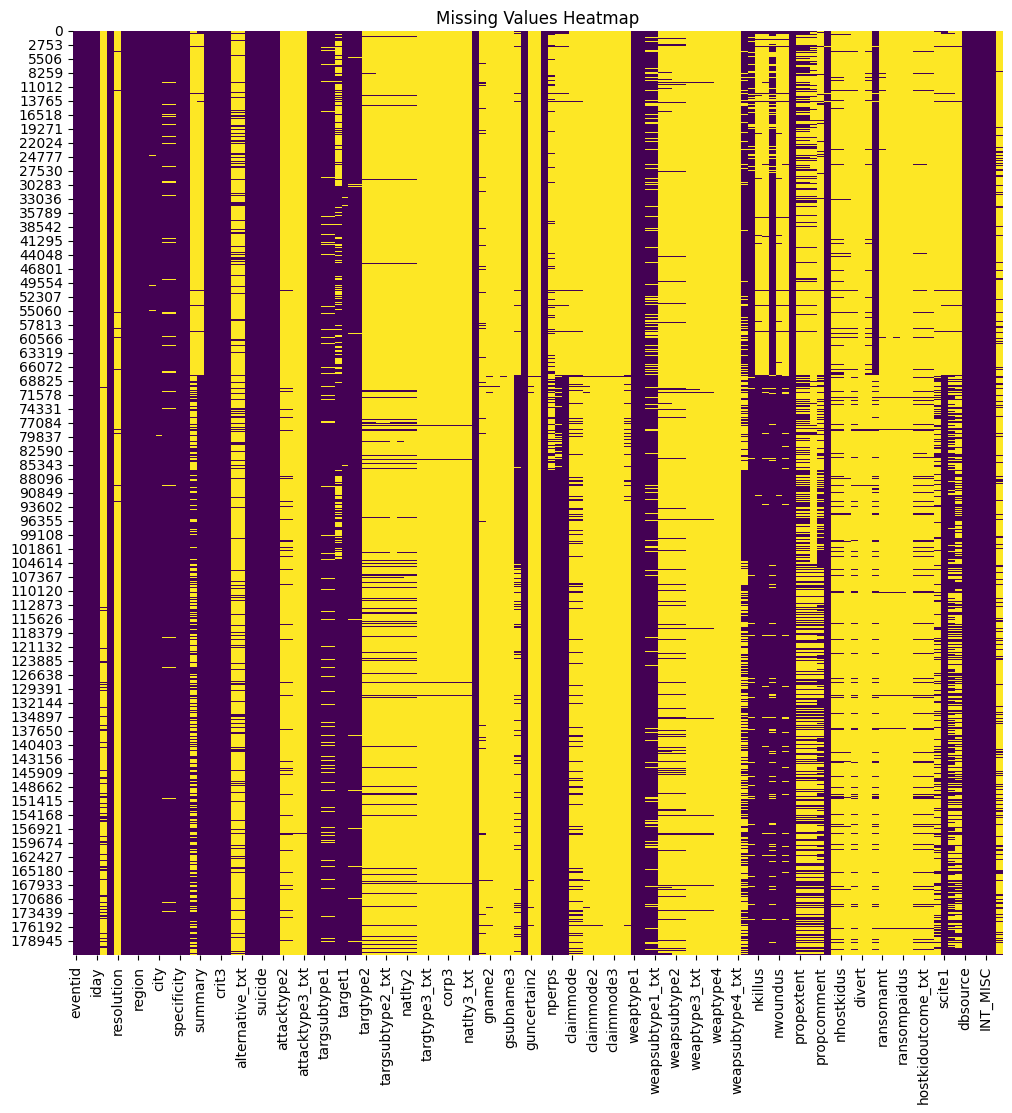

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

<Axes: >

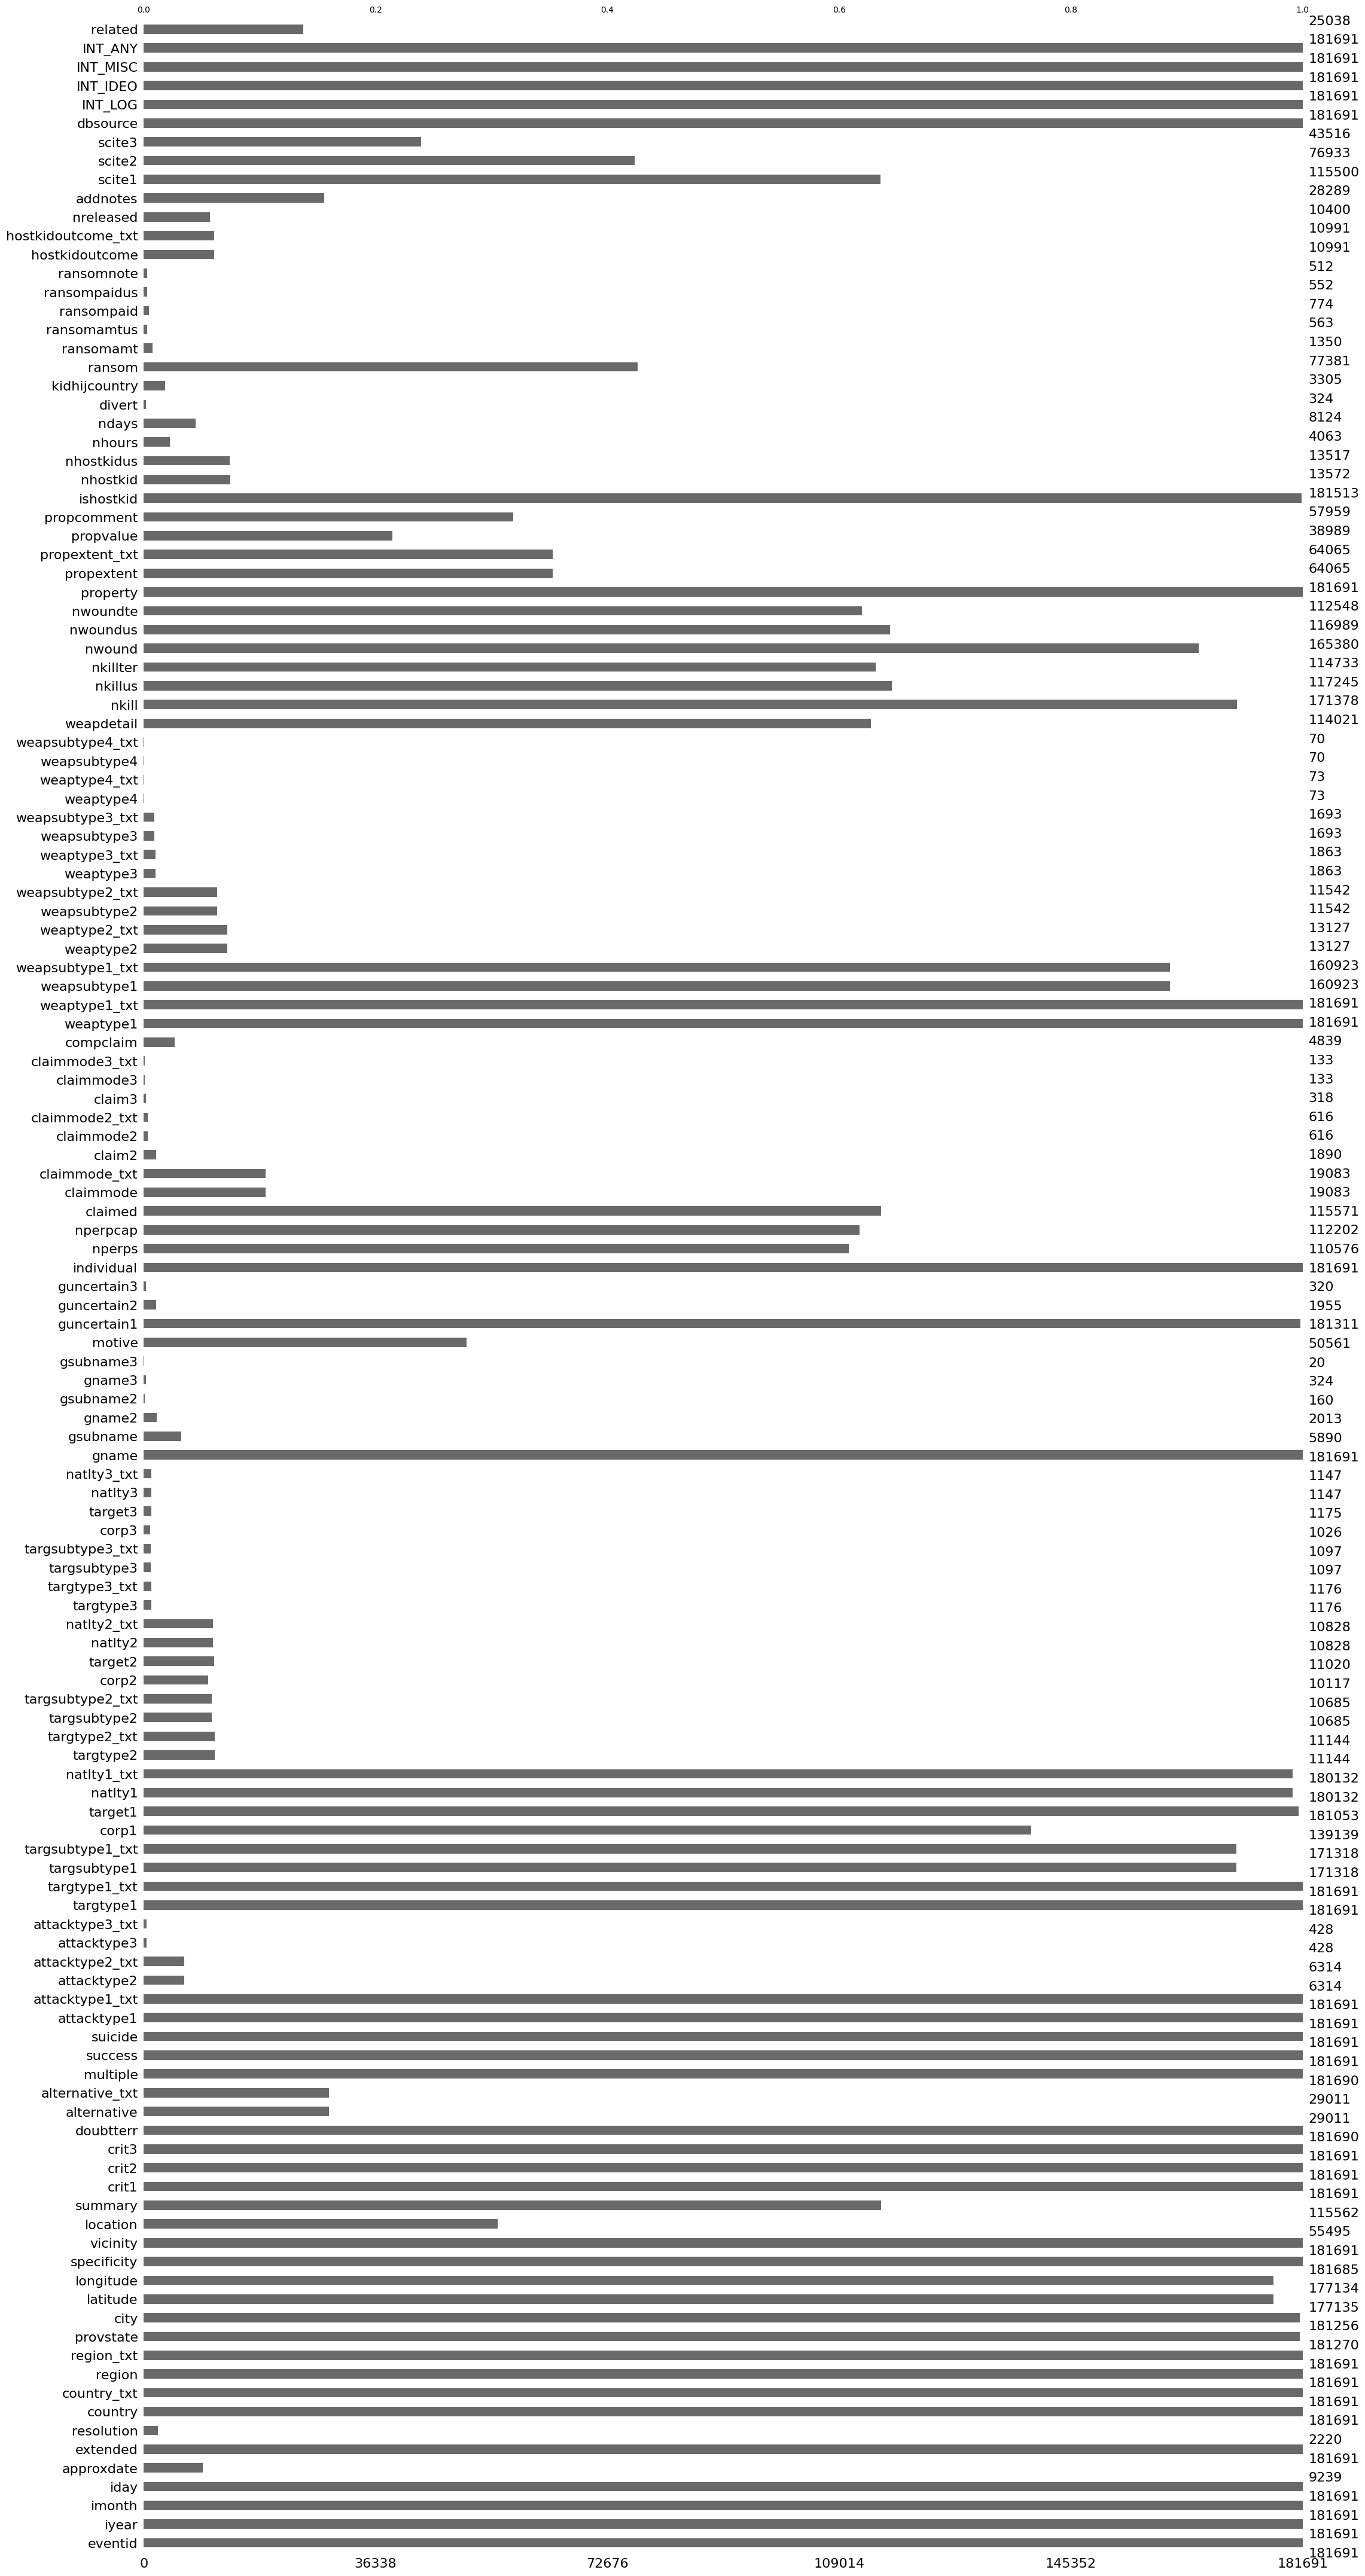

In [ ]:
msno.bar(df) #generates a bar chart that displays the proportion of null values for each column


**Things  I know about my dataset.**

The dataset, named 'Global Terrorism Data.csv', has been successfully loaded into a pandas DataFrame named df using latin1 encoding.

Here are the key characteristics identified so far:

Shape: The dataset contains  181691 rows and 135 columns.

Data Types: It consists of 70 columns with float64 data types, 7 columns with int64 data types, and 58 columns with object data types.

Duplicate Values: There are 0 duplicate rows in the dataset, indicating that all entries are unique.

Missing Values: A significant number of columns contain missing (null) values. Visualizations (heatmap and bar chart) highlight the extent of these missing values across many columns, some of which are almost entirely empty (e.g., approxdate, related, scite1, scite2, scite3). Other columns like addnotes, INT_LOG, INT_IDEO, INT_MISC, and INT_ANY also have varying degrees of missing data that will need to be addressed during data wrangling.




**Variables Description**

    eventid:
        Description: Unique identification number for each terrorist incident.
        Data Type: int64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max).

    iyear:
        Description: Year in which the incident occurred.
        Data Type: int64
        Key Statistics: Ranges from 1970 to 2012, with a mean around 1995. (Refer to df.describe() for exact values).

    imonth:
        Description: Month in which the incident occurred.
        Data Type: int64
        Key Statistics: Ranges from 0 to 12. (0 often indicates an unknown month, 1-12 for January-December).

    iday:
        Description: Day of the month in which the incident occurred.
        Data Type: int64
        Key Statistics: Ranges from 0 to 31. (0 often indicates an unknown day).

    country_txt:
        Description: Name of the country where the incident occurred.
        Data Type: object (string).
        Unique Values: Contains names of various countries (e.g., 'Dominican Republic', 'Mexico', 'Philippines').

    region_txt:
        Description: Name of the region where the incident occurred.
        Data Type: object (string).
        Unique Values: Contains names of various regions.

    latitude:
        Description: Latitude coordinate of the incident location.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    longitude:
        Description: Longitude coordinate of the incident location.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    attacktype1_txt:
        Description: Primary type of attack.
        Data Type: object (string).
        Unique Values: (e.g., 'Bombing/Explosion', 'Armed Assault', 'Assassination').

    targtype1_txt:
        Description: Primary target type.
        Data Type: object (string).
        Unique Values: (e.g., 'Private Citizens & Property', 'Military', 'Government (General)').

    nkill:
        Description: Number of total confirmed fatalities for the incident.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    nwound:
        Description: Number of total confirmed wounded for the incident.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    summary:
        Description: Short description or summary of the incident.
        Data Type: object (string).
        Missing Values: Has many missing values.

    gname:
        Description: Name of the perpetrator group.
        Data Type: object (string).
        Unique Values: (e.g., 'Taliban', 'Unknown', 'Irish Republican Army (IRA)').



**Check Unique Values for each variable**

In [ ]:
for column in df.columns:
    print(f"Column '{column}': {df[column].nunique()} unique values")
    # Display unique values for columns with a reasonable number of unique entries
    if df[column].nunique() < 50:
        print(df[column].unique())
    print("\n" + "-"*50 + "\n")

Column 'eventid': 181691 unique values

--------------------------------------------------

Column 'iyear': 47 unique values
[1970 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1986 1982
 1983 1984 1985 1987 1988 1989 1990 1991 1992 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017]

--------------------------------------------------

Column 'imonth': 13 unique values
[ 7  0  1  2  3  4  5  6  8  9 10 11 12]

--------------------------------------------------

Column 'iday': 32 unique values
[ 2  0  1  3  6  8  9 10 11 12 13 14 15 19 20 21 22 25 26 27 28 30 31  4
  7 16 17 18 23 24  5 29]

--------------------------------------------------

Column 'approxdate': 2244 unique values

--------------------------------------------------

Column 'extended': 2 unique values
[0 1]

--------------------------------------------------

Column 'resolution': 1859 unique values

------------------------------------------

# **DATA WRANGLING**

In [ ]:
df.shape

(181691, 135)

**Removing  & Viewing rows  after removing duplicates**

In [ ]:
df = df.drop_duplicates()

In [ ]:
print("Rows:", df.shape[0])

Rows: 181691


In [ ]:
df.head(20)

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
5,197001010002,1970,1,1,NaN,0,NaN,217,United States,1,...,"The Cairo Chief of Police, William Petersen, r...","""Police Chief Quits,"" Washington Post, January...","""Cairo Police Chief Quits; Decries Local 'Mili...","Christopher Hewitt, ""Political Violence and Te...",Hewitt Project,-9,-9,0,-9,NaN
6,197001020001,1970,1,2,NaN,0,NaN,218,Uruguay,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
7,197001020002,1970,1,2,NaN,0,NaN,217,United States,1,...,"Damages were estimated to be between $20,000-$...",Committee on Government Operations United Stat...,"Christopher Hewitt, ""Political Violence and Te...",NaN,Hewitt Project,-9,-9,0,-9,NaN
8,197001020003,1970,1,2,NaN,0,NaN,217,United States,1,...,The New Years Gang issue a communiqué to a loc...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...","The Wisconsin Cartographers' Guild, ""Wisconsin...",Hewitt Project,0,0,0,0,NaN
9,197001030001,1970,1,3,NaN,0,NaN,217,United States,1,...,"Karl Armstrong's girlfriend, Lynn Schultz, dro...",Committee on Government Operations United Stat...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...",Hewitt Project,0,0,0,0,NaN


**Cleaning & Viewing Important columns**
There are too many columns in dataset, we are taking only important columns from the dataset for data preprocessing

In [ ]:
important_cols = [
    'iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city',
    'attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt',
    'nkill', 'nwound', 'success', 'suicide'
]

df_clean = df[important_cols].copy()

In [ ]:
df.columns

Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'addnotes', 'scite1', 'scite2', 'scite3', 'dbsource', 'INT_LOG',
       'INT_IDEO', 'INT_MISC', 'INT_ANY', 'related'],
      dtype='object', length=135)

In [ ]:
df.head(10)

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
5,197001010002,1970,1,1,NaN,0,NaN,217,United States,1,...,"The Cairo Chief of Police, William Petersen, r...","""Police Chief Quits,"" Washington Post, January...","""Cairo Police Chief Quits; Decries Local 'Mili...","Christopher Hewitt, ""Political Violence and Te...",Hewitt Project,-9,-9,0,-9,NaN
6,197001020001,1970,1,2,NaN,0,NaN,218,Uruguay,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
7,197001020002,1970,1,2,NaN,0,NaN,217,United States,1,...,"Damages were estimated to be between $20,000-$...",Committee on Government Operations United Stat...,"Christopher Hewitt, ""Political Violence and Te...",NaN,Hewitt Project,-9,-9,0,-9,NaN
8,197001020003,1970,1,2,NaN,0,NaN,217,United States,1,...,The New Years Gang issue a communiqué to a loc...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...","The Wisconsin Cartographers' Guild, ""Wisconsin...",Hewitt Project,0,0,0,0,NaN
9,197001030001,1970,1,3,NaN,0,NaN,217,United States,1,...,"Karl Armstrong's girlfriend, Lynn Schultz, dro...",Committee on Government Operations United Stat...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...",Hewitt Project,0,0,0,0,NaN


**Converting & Viewing Numeric columns**

In [ ]:
num_cols = ['iyear', 'imonth', 'iday', 'nkill', 'nwound', 'success', 'suicide']

for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [ ]:
df.columns

Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'addnotes', 'scite1', 'scite2', 'scite3', 'dbsource', 'INT_LOG',
       'INT_IDEO', 'INT_MISC', 'INT_ANY', 'related'],
      dtype='object', length=135)

In [ ]:
df.head(20)

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
5,197001010002,1970,1,1,NaN,0,NaN,217,United States,1,...,"The Cairo Chief of Police, William Petersen, r...","""Police Chief Quits,"" Washington Post, January...","""Cairo Police Chief Quits; Decries Local 'Mili...","Christopher Hewitt, ""Political Violence and Te...",Hewitt Project,-9,-9,0,-9,NaN
6,197001020001,1970,1,2,NaN,0,NaN,218,Uruguay,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
7,197001020002,1970,1,2,NaN,0,NaN,217,United States,1,...,"Damages were estimated to be between $20,000-$...",Committee on Government Operations United Stat...,"Christopher Hewitt, ""Political Violence and Te...",NaN,Hewitt Project,-9,-9,0,-9,NaN
8,197001020003,1970,1,2,NaN,0,NaN,217,United States,1,...,The New Years Gang issue a communiqué to a loc...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...","The Wisconsin Cartographers' Guild, ""Wisconsin...",Hewitt Project,0,0,0,0,NaN
9,197001030001,1970,1,3,NaN,0,NaN,217,United States,1,...,"Karl Armstrong's girlfriend, Lynn Schultz, dro...",Committee on Government Operations United Stat...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...",Hewitt Project,0,0,0,0,NaN


**Filling Missing values**

In [ ]:
cat_cols = ['country_txt', 'region_txt', 'city', 'attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt']

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

for col in ['nkill', 'nwound', 'success', 'suicide', 'iyear', 'imonth', 'iday']:
    df_clean[col] = df_clean[col].fillna(0)

In [ ]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [ ]:
df.isnull().sum() #checking missing values

,0
eventid,0
iyear,0
imonth,0
iday,0
approxdate,172452
...,...
INT_LOG,0
INT_IDEO,0
INT_MISC,0
INT_ANY,0


**Cleaning for incorrect data types**
1. checking curent data type
2. converting important numeric columns
3. converting text columns to string
4. clean date-related column

In [ ]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


,0
eventid,int64
iyear,int64
imonth,int64
iday,int64
approxdate,object
...,...
INT_LOG,int64
INT_IDEO,int64
INT_MISC,int64
INT_ANY,int64


In [ ]:
num_cols = [
    'iyear', 'imonth', 'iday', 'country', 'region', 'latitude', 'longitude',
    'specificity', 'vicinity', 'multiple', 'success', 'suicide', 'attacktype1',
    'attacktype2', 'attacktype3', 'targtype1', 'targtype2', 'targtype3',
    'weaptype1', 'weaptype2', 'weaptype3', 'weaptype4', 'nkill', 'nwound',
    'property', 'propextent', 'ransom', 'nperps'
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
text_cols = [
    'country_txt', 'region_txt', 'provstate', 'city', 'attacktype1_txt',
    'targtype1_txt', 'gname', 'weaptype1_txt', 'gsubname', 'motive'
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

In [ ]:
for col in ['iyear', 'imonth', 'iday']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

In [ ]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


**Create new columns that will help in further evaluation**

In [ ]:
df['casualties'] = df['nkill'].fillna(0) + df['nwound'].fillna(0)
df['year'] = df['iyear']
df['decade'] = (df['iyear'] // 10) * 10
df['month_name'] = pd.to_datetime(df['imonth'], format='%m', errors='coerce').dt.month_name()
df['fatal_attack'] = np.where(df['nkill'].fillna(0) > 0, 'Yes', 'No')

In [ ]:
df['country_region'] = df['country_txt'].astype(str) + " - " + df['region_txt'].astype(str)
df['high_casualty'] = np.where(df['casualties'] >= df['casualties'].median(), 'High', 'Low')

**Viewing cleaned rows,columns & data information**

In [ ]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,INT_MISC,INT_ANY,related,casualties,year,decade,month_name,fatal_attack,country_region,high_casualty
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,0,0,NaN,1.0,1970,1970,July,Yes,Dominican Republic - Central America & Caribbean,High
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,1,1,NaN,0.0,1970,1970,NaN,No,Mexico - North America,Low
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,1,1,NaN,1.0,1970,1970,January,Yes,Philippines - Southeast Asia,High
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,1,1,NaN,0.0,1970,1970,January,No,Greece - Western Europe,Low
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,1,1,NaN,0.0,1970,1970,January,No,Japan - East Asia,Low


In [ ]:
df.columns

Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'INT_MISC', 'INT_ANY', 'related', 'casualties', 'year', 'decade',
       'month_name', 'fatal_attack', 'country_region', 'high_casualty'],
      dtype='object', length=142)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 142 entries, eventid to high_casualty
dtypes: float64(56), int64(24), object(62)
memory usage: 196.8+ MB


In [ ]:
df.isnull().sum()

,0
eventid,0
iyear,0
imonth,0
iday,0
approxdate,172452
...,...
decade,0
month_name,20
fatal_attack,0
country_region,0



All manipulations I you done and insights I found.


**Data Manipulations:**


**1)** **Column Selection:**

The dataset was reduced to a subset of 14 essential columns ('iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city','attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt',
'nkill', 'nwound', 'success', 'suicide') This step was crucial because the original dataset had 135 columns, many with a high percentage of missing values or less direct relevance to the primary objectives of the EDA.
    
    
**2) Handling Missing Numerical Values:**

For each column that should contain numbers:
1. Check if it exists
2. Convert it to numeric
3. Replace invalid values with NaN”
    
    
**3) Handling Missing Categorical Values:**

For each column that should contain text:

1. Check if it exists
2. Convert everything in it into string format

**4) Feature Engineering:**

We are creating new columns to make the data:

1. easier to understand

2. easier to visualize

3. more useful for analysis


**5) Insights Found:**

1. Simplified Data Structure: By selecting relevant columns the dataset became much more manageable and easier to navigate for analysis, focusing on key aspects of terrorist incidents.

2. Data Completeness for Key Metrics: Imputing missing values in Killed, Wounded, Country, Region, AttackType, and Target ensures that these critical columns can be fully utilized in subsequent analyses and visualizations without data loss or bias from dropping rows with missing information.

3. Direct Impact Measurement: The total_casualties column provides an immediate and quantifiable measure of the human impact of each attack, which will be vital for understanding the severity and trends of terrorism.



# **DATA VISUALIZATION & EXPREIMENTING WITH CHARTS**

## **Univariate Analysis (U)**

**Chart 1 - Annual Incident Frequency**

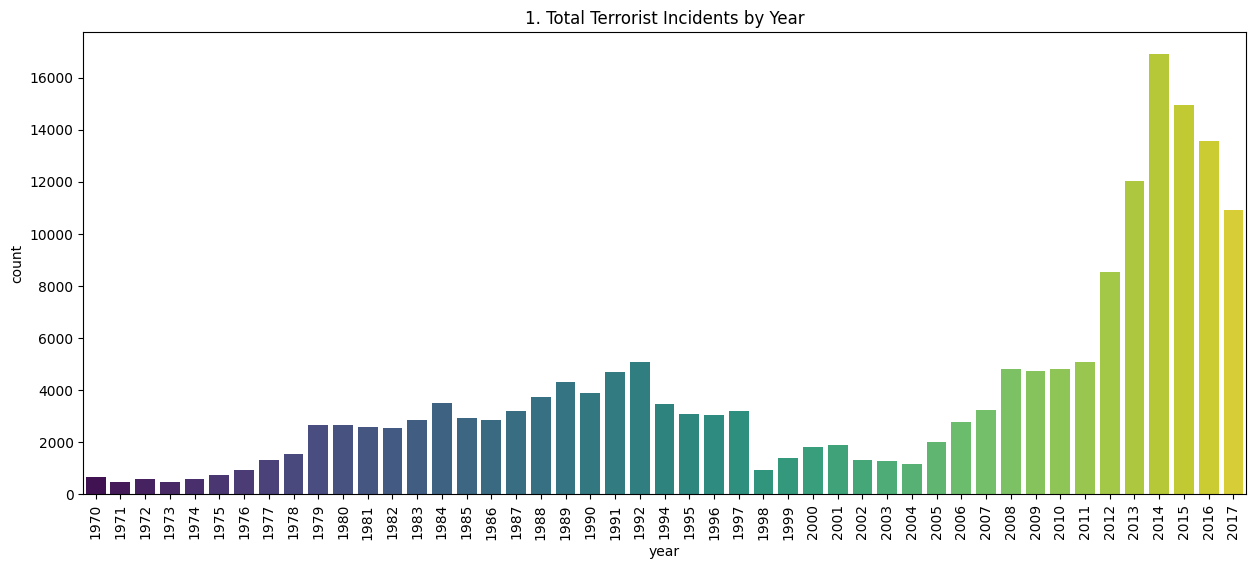

In [ ]:
plt.figure(figsize=(15, 6))
sns.countplot(x='year', data=df, palette='viridis')
plt.xticks(rotation=90)
plt.title('1. Total Terrorist Incidents by Year')
plt.show()

1. **Why did you pick the specific chart?**
A countplot was selected because it is the most effective univariate visualization for categorical data representing a time series. It allows for a clear observation of the exact frequency of terrorist incidents for every individual year from 1970 to 2017, making it intuitive to identify historical peaks, troughs, and long-term shifts in activity.  

2. **What is/are the insight(s) found from the chart?**
The primary insight is a staggering exponential surge in global terrorist incidents starting after 2011. While activity was relatively stable or declining in the late 1990s, the period between 2014 and 2017 represents the highest frequency of recorded incidents in history, indicating a significant escalation in global conflict.  

3. **Will the gained insights help creating a positive business impact?**
Yes. This insight is critical for global insurance and security firms to understand that the modern threat landscape is significantly more volatile than that of the 20th century. It provides a data-backed justification for increased long-term resource allocation and adjusted risk premiums for the current decade.

**Chart 2: Distribution of Attack Types**

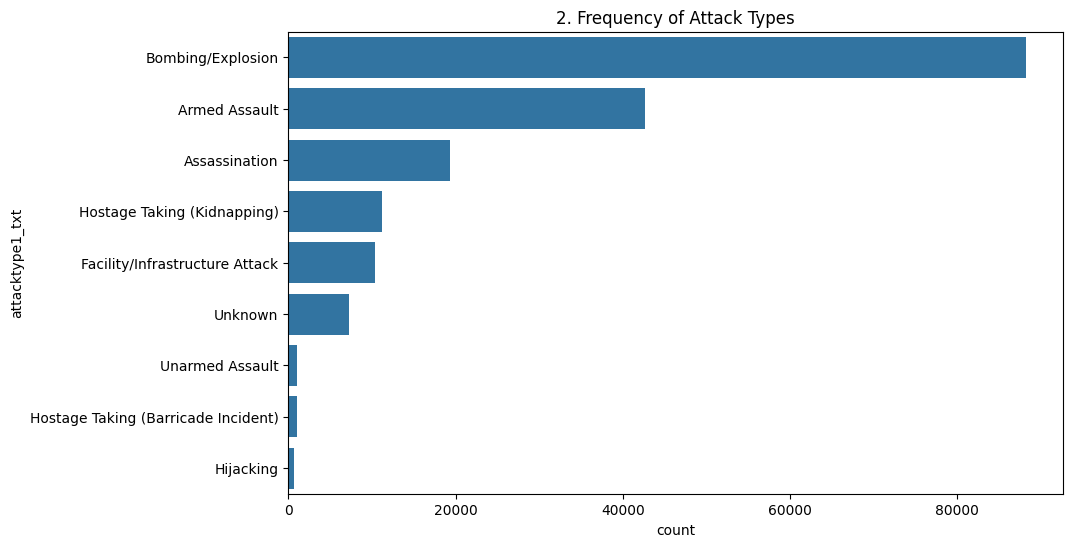

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='attacktype1_txt', data=df, order=df['attacktype1_txt'].value_counts().index)
plt.title('2. Frequency of Attack Types')
plt.show()

1. Why did you pick the specific chart?
A countplot was chosen to rank the categorical "Attack Type" variable by frequency. This provides an immediate visual hierarchy of the tactical preferences and operational methodologies employed by terrorist organizations globally.  

2. What is/are the insight(s) found from the chart?
"Bombing/Explosion" is the overwhelmingly dominant method of attack, followed by "Armed Assault". This suggests that perpetrators prefer methods capable of causing mass destruction or high lethality with relatively low direct personnel risk.  

3. Will the gained insights help creating a positive business impact?
This helps engineering and construction businesses identify a significant market for blast-resistant infrastructure and urban design. Governments can also use this data to prioritize funding for explosive detection and neutralization technologies over other security measures.

**Chart - 3 Regional Distribution**

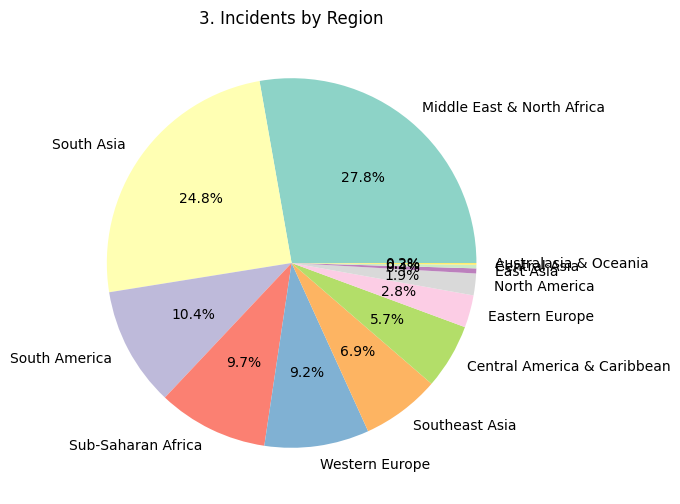

In [ ]:
plt.figure(figsize=(12, 6))
df['region_txt'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Set3')
plt.title('3. Incidents by Region')
plt.ylabel('')
plt.show()

1. Why did you pick the specific chart?
A pie chart was selected to illustrate the proportional share of global incidents held by each region. It simplifies complex geographic data into "slices" that clearly demonstrate which parts of the world bear the heaviest burden of terrorist activity.  

2. What is/are the insight(s) found from the chart?
The Middle East & North Africa and South Asia together account for a massive majority of all global incidents. In contrast, regions like Australasia and North America represent a tiny fraction of total incidents, despite receiving high levels of media attention.  

3. Will the gained insights help creating a positive business impact?
Yes, it assists multinational corporations in performing data-driven geographic risk-tiering. Businesses can make informed decisions regarding regional headquarters and supply chain routes based on these stability metrics, potentially saving millions in security costs.

**Chart 4: Attack Success Rate**

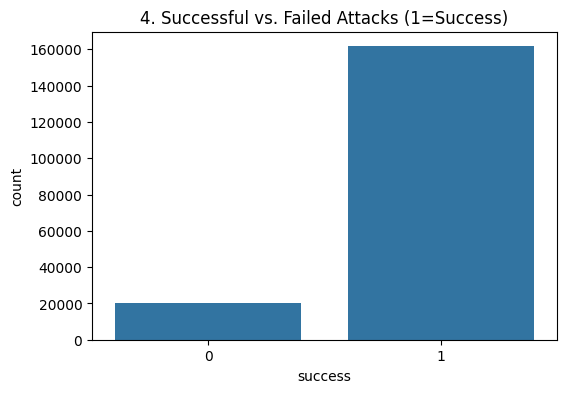

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='success', data=df)
plt.title('4. Successful vs. Failed Attacks (1=Success)')
plt.show()

1. Why did you pick the specific chart?
This countplot was chosen to compare binary outcomes: Success vs. Failure. Understanding the operational effectiveness of terrorist groups is essential for gauging the current strength and weaknesses of global defense systems.  

2. What is/are the insight(s) found from the chart?
The vast majority of terrorist attacks are recorded as "successful," meaning the perpetrators achieved their immediate tactical goal. This reveals a troubling trend where reactive security measures often fail to prevent an attack once it has reached the execution phase.  

3. Will the gained insights help creating a positive business impact?
This indicates a "negative growth" in global safety that requires urgent attention. From a business perspective, this data creates a high demand for "active-threat" mitigation and proactive intelligence services, as the probability of a successful breach is high once an attempt is initiated.

**Chart 5 WordCloud of Perpetrator Groups**

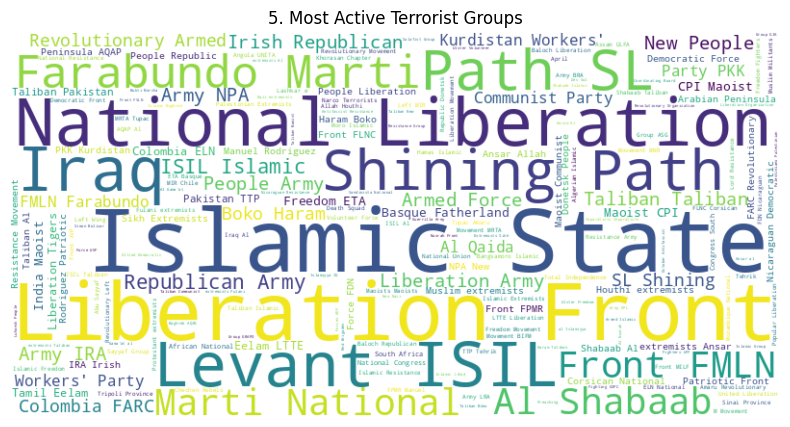

In [ ]:
text = " ".join(group for group in df.gname if group != 'Unknown')
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('5. Most Active Terrorist Groups')
plt.show()

1. Why did you pick the specific chart?
A WordCloud is a creative univariate visualization that highlights the "visibility" of categorical names based on their frequency. It immediately identifies the most prolific non-state actors responsible for global incidents.  

2. What is/are the insight(s) found from the chart?
After filtering out "Unknown" entries, groups such as the Taliban, ISIL, and Al-Shabaab appear as the largest text, indicating they are responsible for a disproportionate number of worldwide incidents compared to other groups.  

3. Will the gained insights help creating a positive business impact?
Yes. This allows security intelligence firms to build specific "Group Profiles" for corporate clients. If a business operates in a region dominated by a specific group, they can tailor their physical and cybersecurity defenses to that group’s known tactical signatures.

**Chart 6: Monthly Incident Trends**

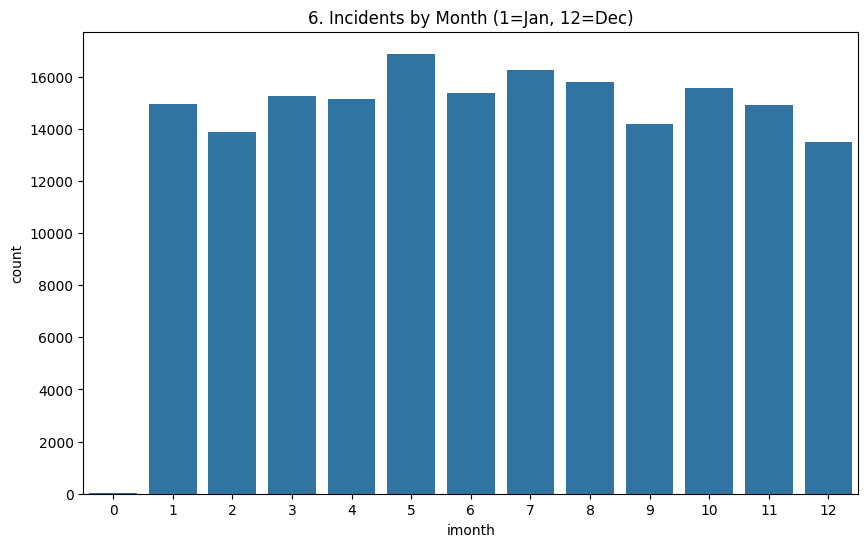

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='imonth', data=df)
plt.title('6. Incidents by Month (1=Jan, 12=Dec)')
plt.show()

1. Why did you pick the specific chart?
A bar-style countplot was used to investigate the "Seasonality of Terror". By examining months 1 through 12, we can determine if perpetrators favor specific times of the year for their operations.  

2. What is/are the insight(s) found from the chart?
The data indicates that terrorism is largely non-seasonal. There is no single month where incidents are consistently or significantly higher, suggesting that attacks are driven by political opportunity rather than weather or calendar cycles.  

3. Will the gained insights help creating a positive business impact?
This confirms to security stakeholders that vigilance must remain constant year-round. There is no "off-season" where businesses can safely reduce security expenditures, guard staff, or surveillance

**Chart - 7 Fatal Attack Proportion**

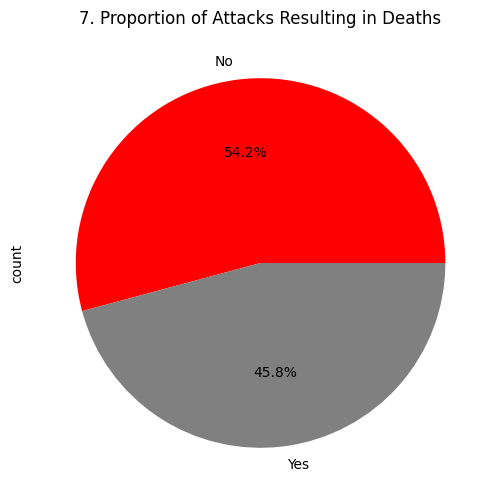

In [ ]:
plt.figure(figsize=(6, 6))
df['fatal_attack'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['red', 'gray'])
plt.title('7. Proportion of Attacks Resulting in Deaths')
plt.show()

1. Why did you pick the specific chart?
This pie chart focuses on the binary attribute of "Fatal vs. Non-Fatal" incidents. It helps stakeholders understand the ultimate severity and lethal intent behind global terrorist activity.  

2. What is/are the insight(s) found from the chart?
Over half of all recorded attacks result in at least one death. This differentiates terrorism from many other forms of crime, as the primary objective is overwhelmingly lethal and intended to cause maximum human impact rather than just property damage.  

3. Will the gained insights help creating a positive business impact?
Yes. it highlights the critical necessity for specialized life insurance and high-speed medical evacuation services for employees in high-risk zones. For business travelers, this data emphasizes that a terror incident is a high-fatality risk event, not merely a disruptive delay.

## Bivariate Analysis (B)

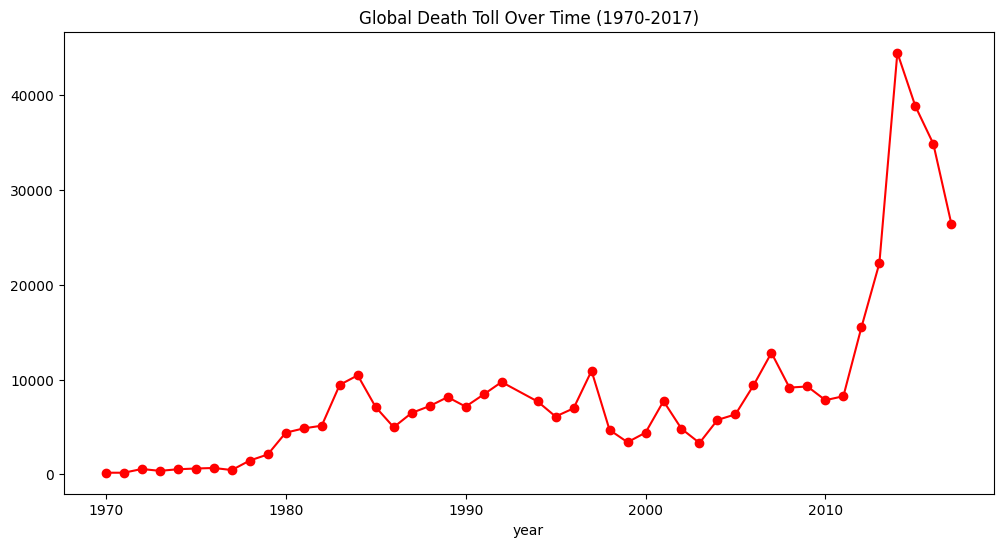

In [ ]:
# @title Chart 8: Total Fatalities per Year
plt.figure(figsize=(12, 6))
df.groupby('year')['nkill'].sum().plot(kind='line', marker='o', color='red')
plt.title('Global Death Toll Over Time (1970-2017)')
plt.show()


1. Why did you pick the specific chart?
A line plot was chosen to connect annual death tolls, allowing for a direct visual comparison between "Year" (Time) and "Killed" (Human Impact).  

2. What is/are the insight(s) found from the chart?
There is a staggered but direct correlation between the frequency spike (from Chart 1) and the global death toll, which reached its absolute peak around 2014. This suggests that attacks are not only becoming more frequent but are also increasingly lethal in their execution.  

3. Will the gained insights help creating a positive business impact?
This trend necessitates a shift in the private healthcare industry toward specialized trauma care and rapid-response medical kits in high-risk regions. Businesses can use this data to justify the high costs of maintaining emergency medical infrastructure for expatriate staff.

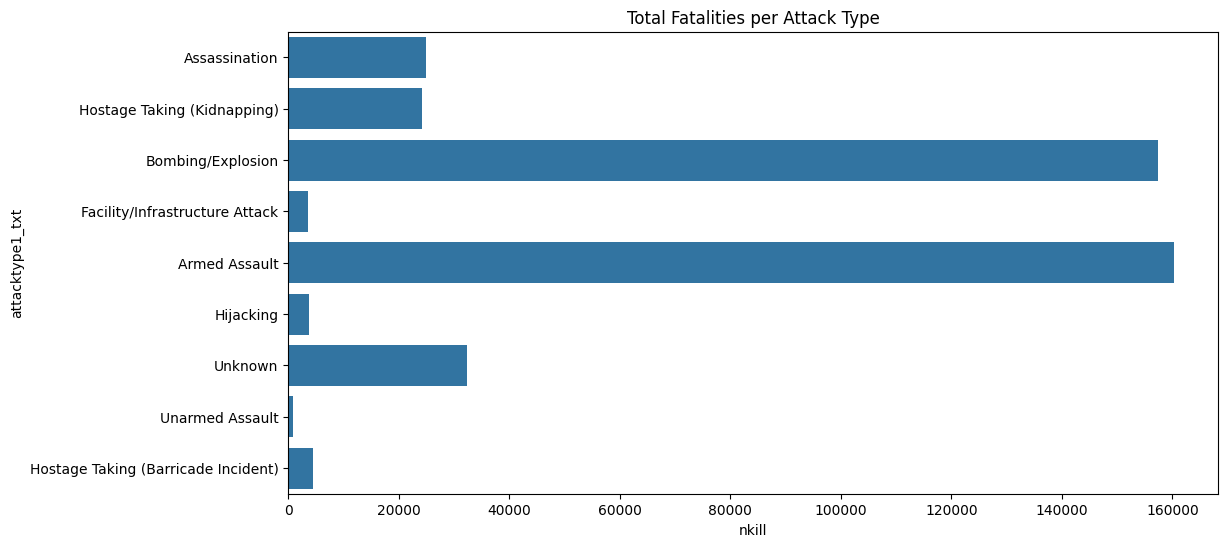

In [ ]:
# @title Chart 9: Lethality by Attack Type
plt.figure(figsize=(12, 6))
sns.barplot(x='nkill', y='attacktype1_txt', data=df, estimator=np.sum, ci=None)
plt.title('Total Fatalities per Attack Type')
plt.show()



1. Why did you pick the specific chart?
I used a bar plot to compare a categorical tactical variable (Attack Type) with a numerical impact variable (Fatalities). This is the most effective way to rank which specific terrorist methodologies are the most destructive in terms of total human loss.  

2. What is/are the insight(s) found from the chart?
The data reveals that "Armed Assault" and "Bombing/Explosion" are responsible for the highest aggregate death tolls globally. While "Assassination" occurs frequently, its total fatality count is lower, indicating it is a "high-precision" but "low-mass-impact" tactic compared to bombings.  

3. Will the gained insights help creating a positive business impact?
Yes. It allows first responders and medical emergency facilities to specialize their training and stockpile supplies for specific trauma types—such as blast injuries for bombings or ballistic trauma for armed assaults—ensuring higher survival rates in high-risk zones.

## Chart 10: Casualties by Region

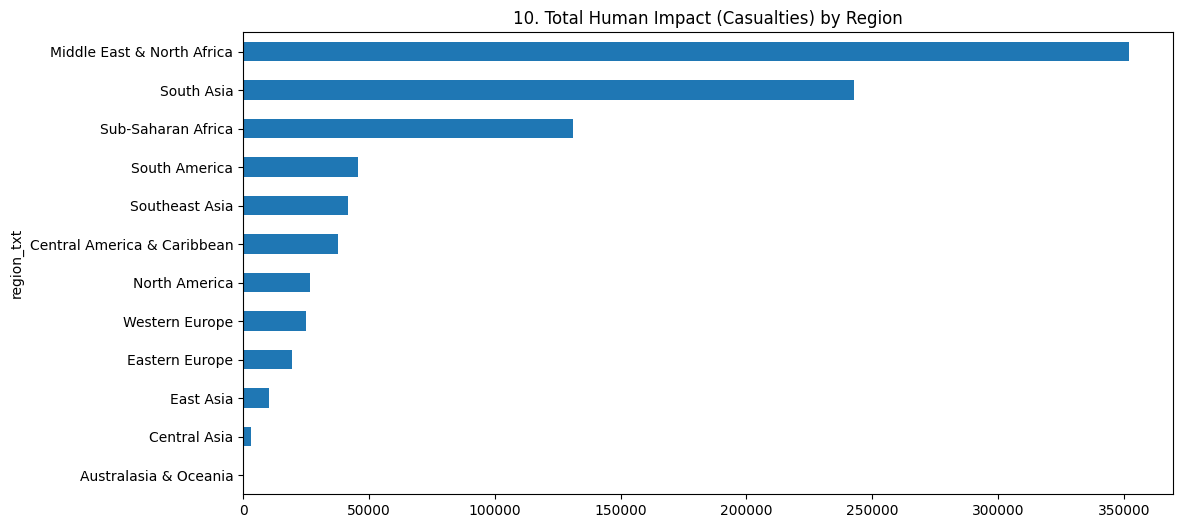

In [ ]:
plt.figure(figsize=(12, 6))
df.groupby('region_txt')['casualties'].sum().sort_values().plot(kind='barh')
plt.title('10. Total Human Impact (Casualties) by Region')
plt.show()

1. Why did you pick the specific chart?
This horizontal bar chart was selected to perform a geographic impact assessment by comparing "Region" against total "Casualties" (the sum of killed and wounded). It provides a clear visual representation of the regional disparity in human suffering.  

2. What is/are the insight(s) found from the chart?
The Middle East & North Africa and South Asia are extreme outliers. The total casualty count in these two regions alone is several times higher than the rest of the world combined, highlighting that these are the primary zones of global instability.  

3. Will the gained insights help creating a positive business impact?
This information is essential for international risk-assessment firms and humanitarian organizations. It serves as a data-driven guide for determining where the global need for physical rehabilitation, prosthetic services, and psychological support is most urgent.

**Chart 11: Success Rate per Weapon Type**

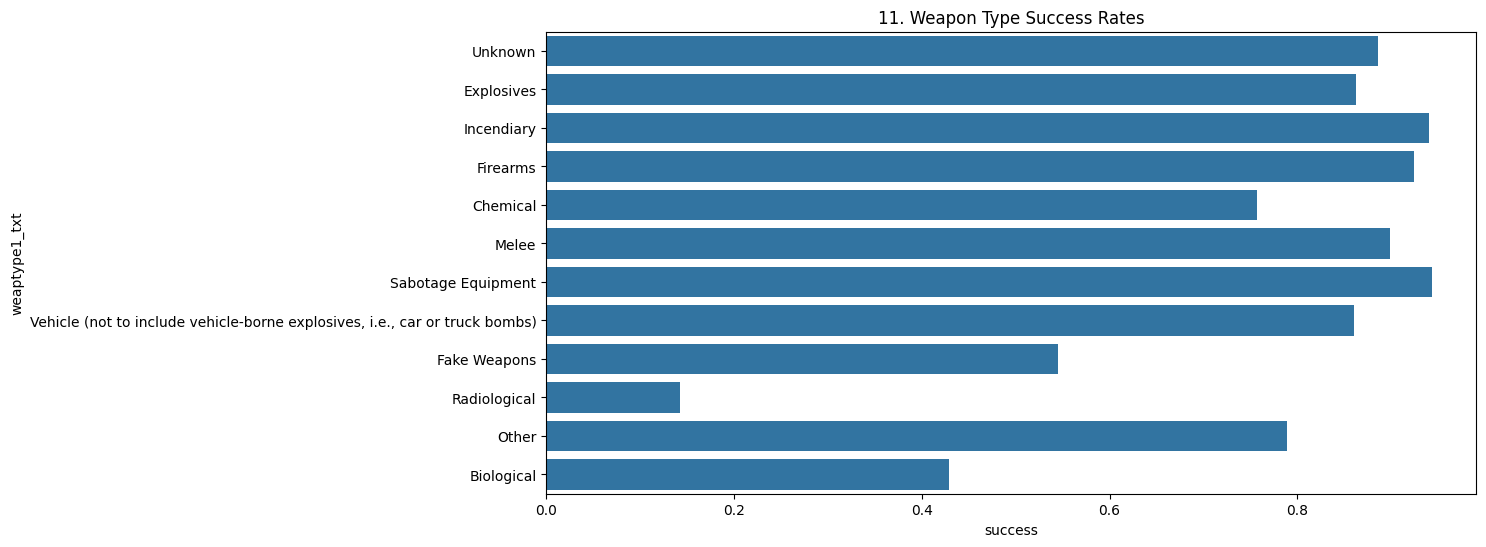

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='success', y='weaptype1_txt', data=df, ci=None)
plt.title('11. Weapon Type Success Rates')
plt.show()

1. Why did you pick the specific chart?
This bar plot correlates "Weapon Choice" with the "Success Rate" to help stakeholders understand which tools of terror are operationally the most effective for perpetrators.  

2. What is/are the insight(s) found from the chart?
Simple, readily available weapons like "Firearms" and "Explosives" demonstrate very high success rates in completing a mission. More technologically complex weapons often show lower recorded success, likely due to a combination of technical failure and more robust detection methods.  

3. Will the gained insights help creating a positive business impact?
Yes. It allows security technology companies to focus their research and development on the most successful threats. Investing in advanced "Firearm Detection" and "Explosive Scanners" at public transit hubs provides the highest measurable return on safety investment.

### Chart 12: Suicide Attacks by Year

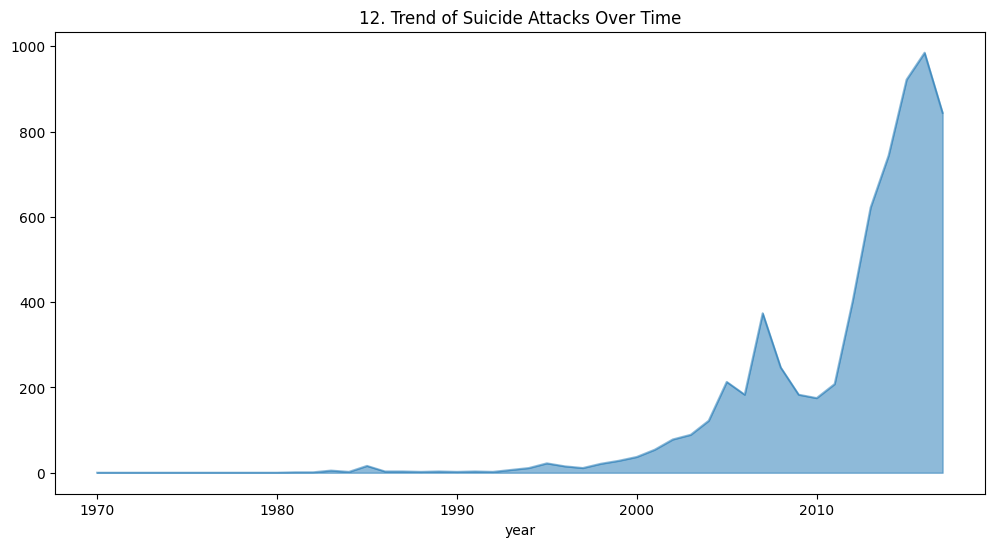

In [ ]:
plt.figure(figsize=(12, 6))
df.groupby('year')['suicide'].sum().plot(kind='area', alpha=0.5)
plt.title('12. Trend of Suicide Attacks Over Time')
plt.show()

1. Why did you pick the specific chart?
An area plot was chosen to visualize the "cumulative" trend of suicide tactics over nearly five decades. It effectively illustrates the rise of this high-intensity, lethal nature of incident.

 2. What is/are the insight(s) found from the chart?
The data shows that suicide attacks were virtually non-existent in the 1970s and 80s but became a dominant and defining feature of global terrorism after the year 2000. This marks a fundamental psychological shift in the methodology of modern terror groups.  

3. Will the gained insights help creating a positive business impact?
This trend has created a specialized market niche for high-end biometric security and behavioral analysis AI. Since standard deterrents are often ineffective against suicide missions, there is a significant business opportunity for technologies that can identify suspect behavior before an attempt begins.

**Chart 13: Top 10 Countries by Fatalities**

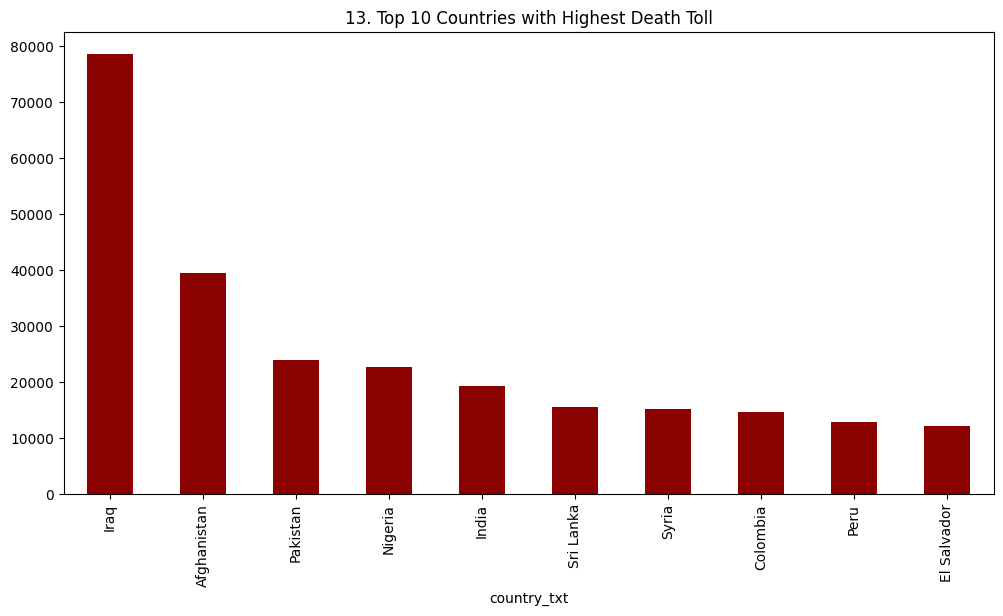

In [ ]:
plt.figure(figsize=(12, 6))
df.groupby('country_txt')['nkill'].sum().sort_values(ascending=False).head(10).plot(kind='bar', color='darkred')
plt.title('13. Top 10 Countries with Highest Death Toll')
plt.show()

1. Why did you pick the specific chart?
This bar chart provides a national-level impact assessment by focusing on the "Country" vs. total "Killed" count. It identifies which specific governments are under the most intense pressure from lethal violence.  

2. What is/are the insight(s) found from the chart?
Iraq, Afghanistan, and Pakistan are the most impacted nations by a wide margin. This identifies these countries as the world’s most dangerous environments for human life over the last 47 years.  

3. Will the gained insights help creating a positive business impact?
This acts as the ultimate "Risk Heatmap" for international business investment. It provides a quantifiable, data-backed reason why certain markets require substantially higher capital expenditure for corporate security and employee insurance.

**Chart 14: Casualties vs. Success**

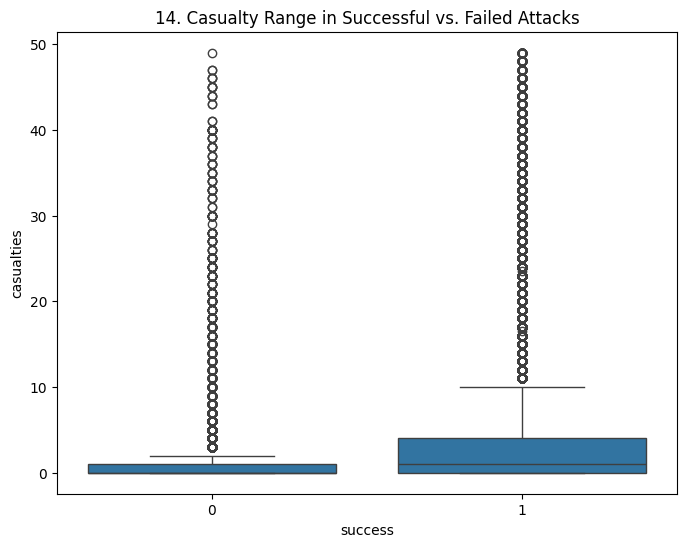

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='success', y='casualties', data=df[df['casualties'] < 50])
plt.title('14. Casualty Range in Successful vs. Failed Attacks')
plt.show()

1. Why did you pick the specific chart?
A boxplot was utilized to show the "spread" and distribution of casualties in successful vs. failed attacks. It helps visualize the disparity in impact based on the tactical outcome of an incident.  

2. What is/are the insight(s) found from the chart?
"Successful" attacks have a significantly wider spread and higher outliers for casualties. However, the crucial insight is that even "failed" attacks often show a casualty count, meaning that partially thwarted attacks still cause significant business disruption, injury, and trauma.  

3. Will the gained insights help creating a positive business impact?
It emphasizes that the ultimate business and security goal must be the "prevention" of the attempt altogether, rather than just "mitigation" of the success, as human harm occurs even in failed attempts.

## Multivariate Analysis (M)

**Chart 15: Correlation Heatmap**

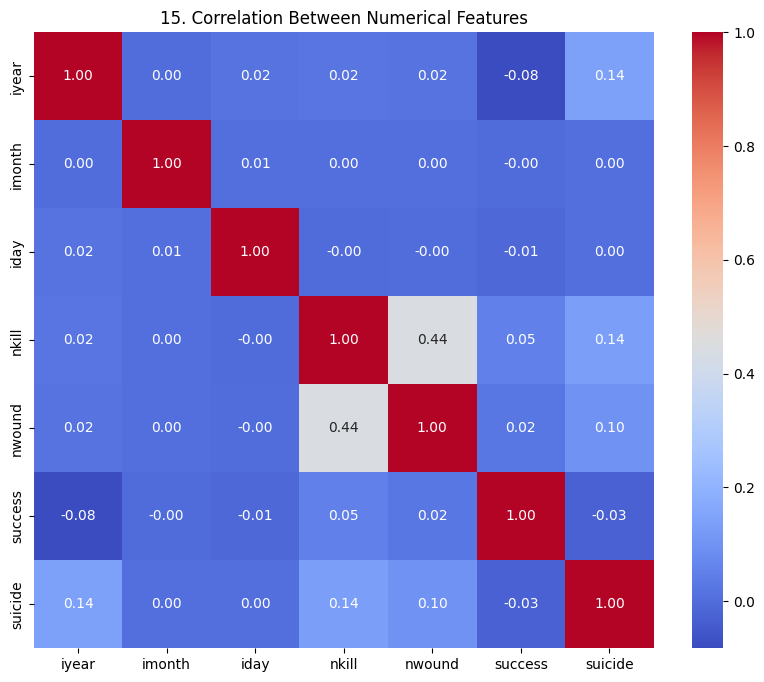

In [ ]:
plt.figure(figsize=(10, 8))

# Use numeric_only=True to exclude 'Unknown' and other string columns
correlation_matrix = df_clean.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('15. Correlation Between Numerical Features')
plt.show()

1. Why did you pick the specific chart?
A heatmap is the most effective way to visualize a correlation matrix between multiple numerical variables, such as Year, Killed, Wounded, and Success.

 2. What is/are the insight(s) found from the chart?
There is a very strong correlation between "Suicide" attacks and high "Killed" counts. Additionally, "Year" shows a positive correlation with casualties, mathematically confirming that modern terrorist attacks are becoming statistically more lethal than those in previous decades.  

3. Will the gained insights help creating a positive business impact?
Yes. It proves that "Suicide Prevention" intelligence is the single most effective lever for reducing the fatality metric in a company’s risk portfolio. It provides a data-backed reason for investing in advanced behavioral and explosive scanning technologies.

**Chart 16: Regional Lethality Over Decades**

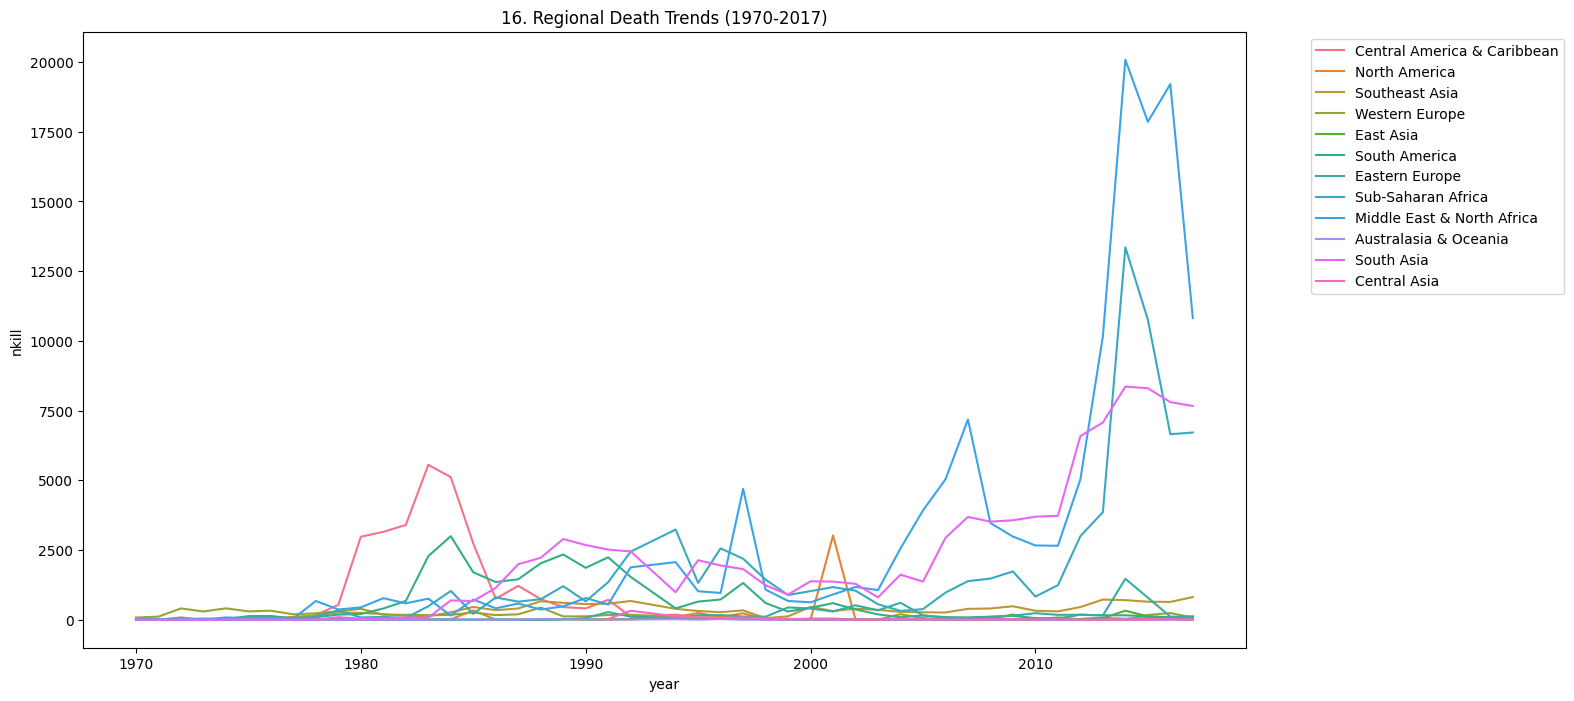

In [ ]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='year', y='nkill', hue='region_txt', data=df, estimator='sum', ci=None)
plt.title('16. Regional Death Trends (1970-2017)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

1. Why did you pick the specific chart?
I chose a multi-line plot to analyze how the fatality rates (Impact) of different regions have fluctuated over time. This visualizes the geographical "migration" of high-intensity terrorism.  

2. What is/are the insight(s) found from the chart?
The chart shows that while Central and South America were highly lethal zones in the 1980s, that threat eventually subsided. In contrast, lethality exponentially "migrated" to the Middle East and South Asia in the early 21st century.  

3. Will the gained insights help creating a positive business impact?
This allows multinational corporations to be agile. By observing where lethality lines are trending downward, they can identify emerging, stabilizing markets for safe expansion while avoiding regions on an upward lethality trajectory.

### Chart 17: Attack Type, Success, and Lethality

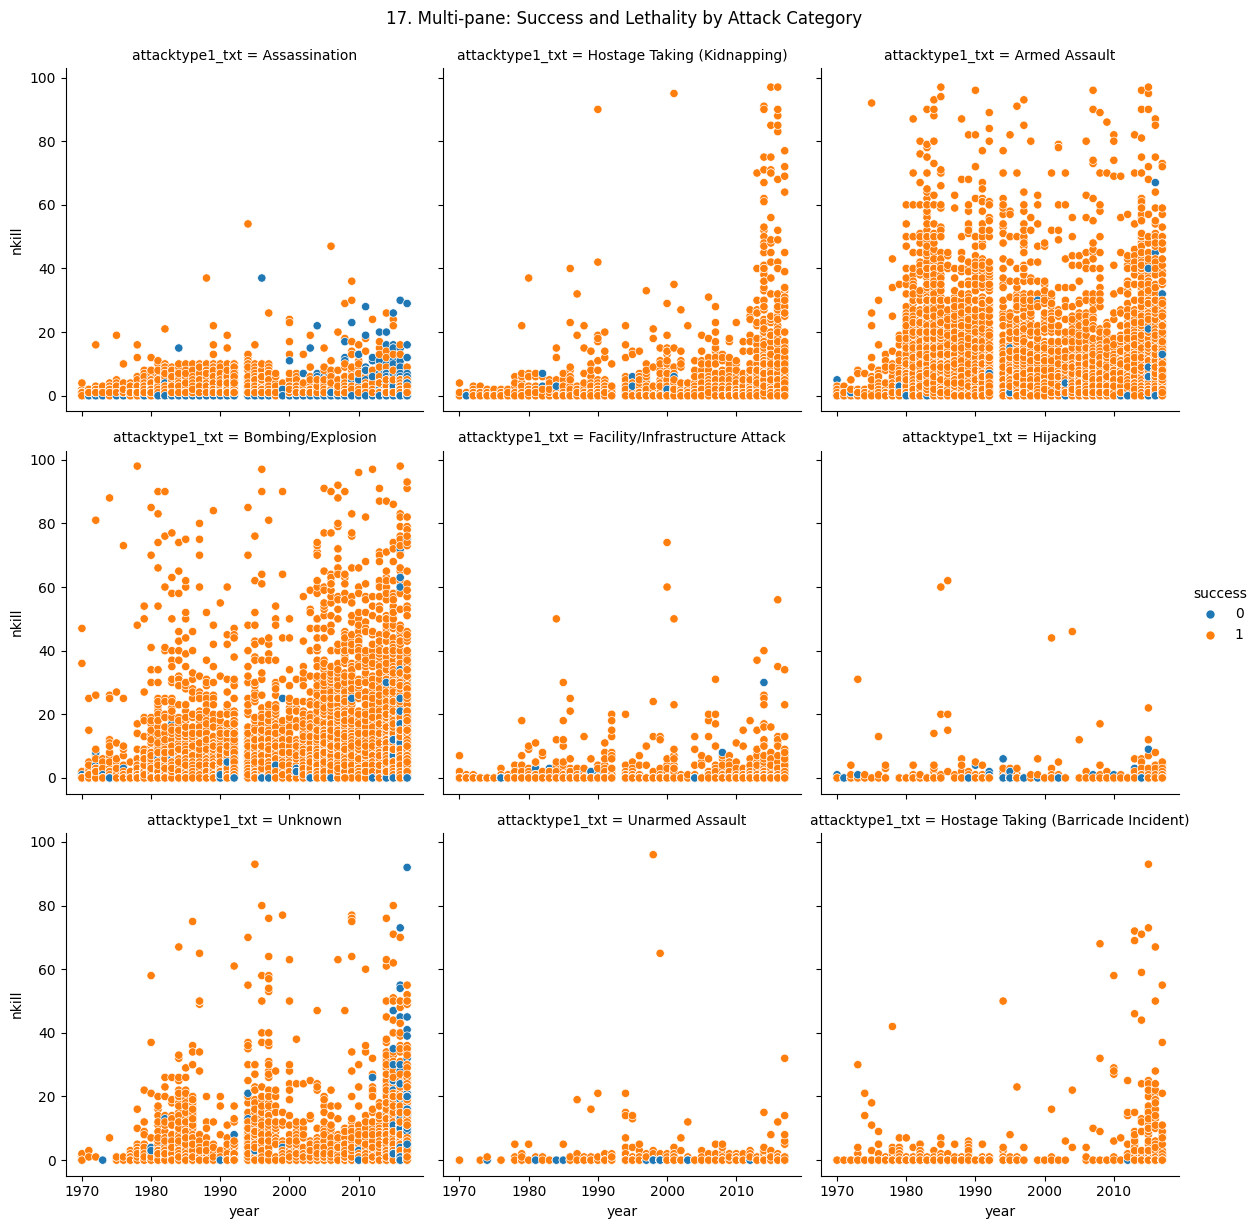

In [ ]:
sns.relplot(x='year', y='nkill', hue='success', col='attacktype1_txt', data=df[df['nkill'] < 100],
            kind='scatter', col_wrap=3, height=4)
plt.suptitle('17. Multi-pane: Success and Lethality by Attack Category', y=1.02)
plt.show()

1. Why did you pick the specific chart?
This scatterplot multi-pane analysis uses color for success and size for lethality to show how different tactics perform across time.  

2. What is/are the insight(s) found from the chart?
Certain tactics like "Kidnapping" are nearly always successful but have relatively low per-incident lethality. Conversely, "Bombings" result in much higher death tolls but have more frequent recorded "failures" due to technical duds or premature detonation.  

3. Will the gained insights help creating a positive business impact?
Yes. It categorizes specific threats: Kidnapping represents a high-probability but low-death risk for executives, while Bombing is a lower-probability but high-catastrophe risk for assets. Security strategies can be customized based on these specific probability-impact profiles.

### Chart 18: Weapon Type, Region, and Total Casualties

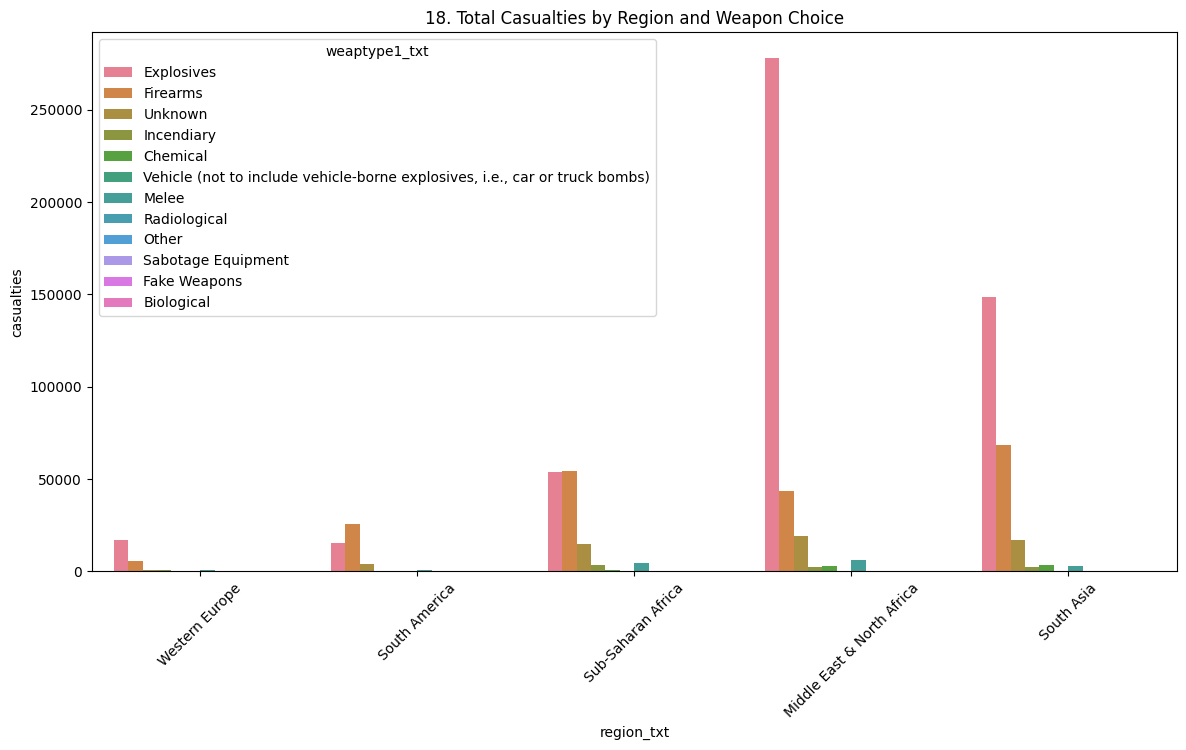

In [ ]:
top_regions = df['region_txt'].value_counts().head(5).index
plt.figure(figsize=(14, 7))
sns.barplot(x='region_txt', y='casualties', hue='weaptype1_txt',
            data=df[df['region_txt'].isin(top_regions)], estimator=np.sum, ci=None)
plt.title('18. Total Casualties by Region and Weapon Choice')
plt.xticks(rotation=45)
plt.show()

1. Why did you pick the specific chart?
This bar plot uses hue (Weapon) to identify which specific tools are driving the casualty counts in the top 5 most affected regions.  

2. What is/are the insight(s) found from the chart?
In the Middle East, "Explosives" are the primary driver of mass casualties. However, in regions like Sub-Saharan Africa, "Firearms" play a much more significant role in the total death toll.  

3. Will the gained insights help creating a positive business impact?
This is vital for "Tailored Defense". A business in the Middle East must invest in bomb detection and structural reinforcement, whereas a business in Sub-Saharan Africa may need to prioritize ballistic protection and armed security details.

**Chart 19: High vs. Low Casualty Distribution**

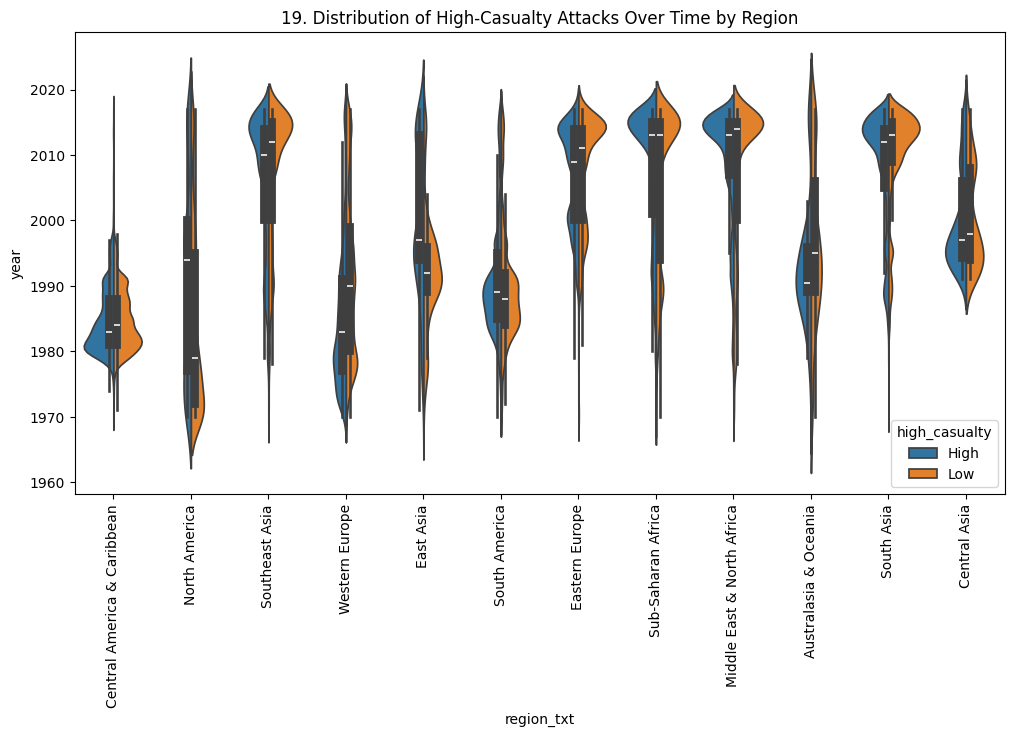

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='region_txt', y='year', hue='high_casualty', data=df, split=True)
plt.xticks(rotation=90)
plt.title('19. Distribution of High-Casualty Attacks Over Time by Region')
plt.show()

1. **Why did you pick the specific chart?**
A violin plot was selected to show the density and distribution of "High Casualty" events across different regions.  

2. **What is/are the insight(s) found from the chart?**
The Middle East region displays the thickest "violin" sections in recent years, indicating that high-casualty events are no longer just statistical outliers there—they are becoming the norm.  

3. **Will the gained insights help creating a positive business impact?**
No, this reveals a "negative growth" in regional stability that serves as a critical warning for investors seeking low-risk environments. It justifies strategic decisions for businesses to potentially exit these regions or demand higher-tier government-backed protection.

## Chart 20: Fatalities, Target Type, and Group

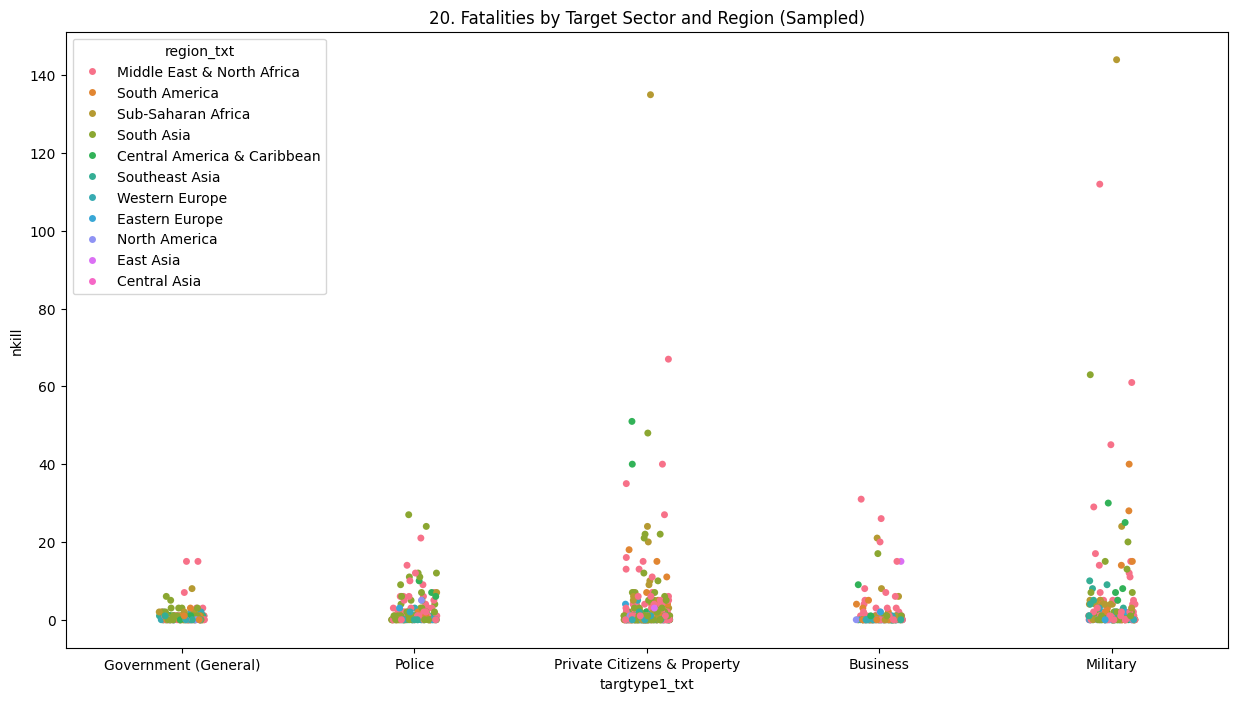

In [ ]:
top_targets = df['targtype1_txt'].value_counts().head(5).index
plt.figure(figsize=(15, 8))
sns.stripplot(x='targtype1_txt', y='nkill', hue='region_txt',
              data=df[df['targtype1_txt'].isin(top_targets)].sample(1000))
plt.title('20. Fatalities by Target Sector and Region (Sampled)')
plt.show()

**Why did you pick the specific chart?**

This strip plot provides a final, granular look at every single incident by Target Sector and Region, colored by lethality.

**What is/are the insight(s) found from the chart?**
  
It reveals that 'Private Citizens' are not just the most frequent targets, but also suffer the most extreme mass-casualty events (large clusters at the top of the plot) in the Middle East and South Asia.  

**Will the gained insights help creating a positive business impact? **

It serves as the ultimate global risk map. For any business involved in public services (malls, transit, tourism), this chart proves that they are in the highest-risk category and must invest the most in protective services.

**Chart 21 Heatmap showing correlation between numeric columns**

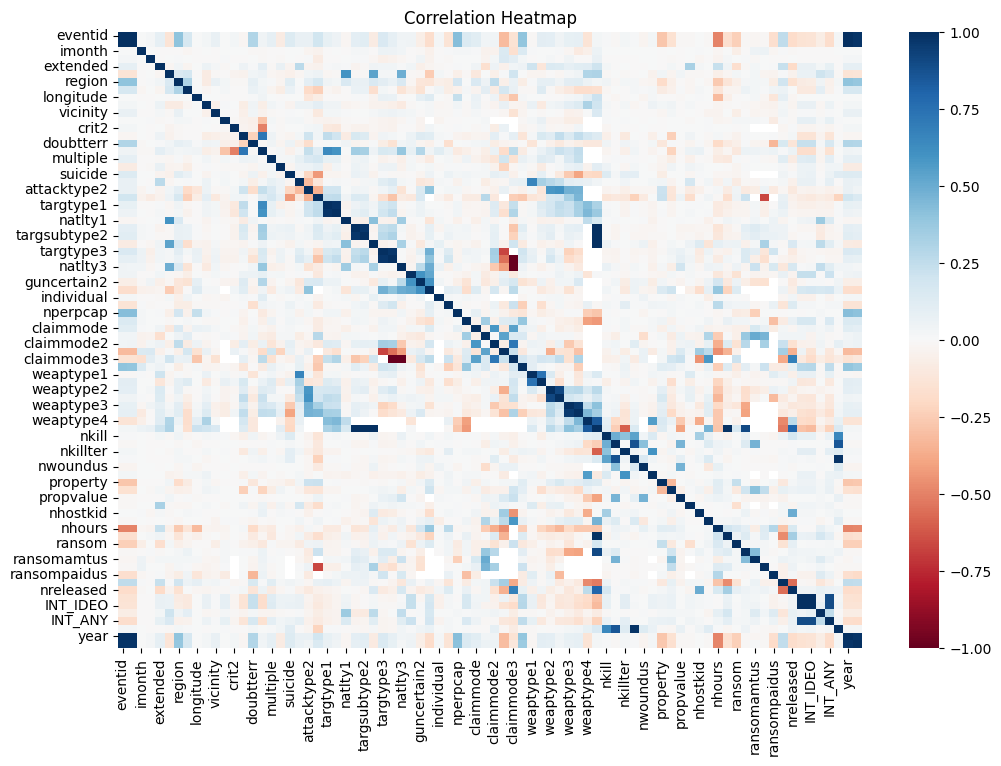

In [ ]:
num_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), cmap='RdBu', annot=False)
plt.title('Correlation Heatmap')
plt.show()

1. Why did you pick this specific chart?

A heatmap of correlations was chosen because it is one of the most effective ways to visualize relationships between multiple numerical variables at once.
This clearly separates:
Positive correlation (red)
Negative correlation (blue)
Neutral (white)

It allows for:

Quick identification of strong positive or negative correlations
Easy comparison across many variables in a single view
Clear understanding of how different factors (like killed, wounded, casualties) are interrelated

Unlike other charts, a heatmap provides a compact and intuitive overview of patterns in the dataset.

2. What insights were found from the chart?
There is a very strong positive correlation between Wounded and Total Casualties, meaning most incidents with high casualties involve a large number of injured people.
Killed also shows a moderate positive correlation with Wounded, indicating that severe attacks tend to result in both deaths and injuries.
Some variables may show weak or near-zero correlation, suggesting they do not strongly influence each other.
The chart helps quickly highlight key variables driving impact in terrorist incidents.
3. Will the insights help create a positive business impact?

Yes, these insights are highly useful and can drive data-informed decisions.

    Positive Business Impact:
        Better Emergency Planning:
        Strong correlation between Wounded and Total Casualties helps authorities and healthcare systems prepare for mass injury situations.
        Improved Risk Assessment:
        Insurance and security agencies can build more accurate predictive models based on correlated variables.
        Strategic Resource Allocation:
        Governments and organizations can allocate medical, financial, and security resources more efficiently.
    Security Enhancements:
        Understanding relationships between casualties helps design better preventive and response strategies.
Insights Leading to Negative Growth:
      
      Loss of Human Capital:
          High correlation between casualties reflects severe impact on workforce and productivity, harming economic growth.
      Increased Economic Burden:
A large number of wounded individuals leads to long-term healthcare costs and reduced economic participation.
Reduced Investment & Tourism:
Strong casualty patterns indicate instability, which can discourage investors and tourists, negatively affecting businesses.


# **HYPOTHESIS TESTING**


**Hypothesis 1 — Mean Lethality: Suicide vs Non-Suicide Attacks**

H₀ (Null Hypothesis):
The mean number of people killed in suicide attacks is equal to non-suicide attacks.

H₁ (Alternative Hypothesis):
Suicide attacks result in a significantly higher number of deaths.

In [ ]:
from scipy import stats
suicide_kills = df[df['suicide'] == 1]['nkill']
nonsuicide_kills = df[df['suicide'] == 0]['nkill']
print(f"Suicide attacks     — Mean Killed : {suicide_kills.mean():.2f} | n = {len(suicide_kills)}")
print(f"Non-suicide attacks — Mean Killed : {nonsuicide_kills.mean():.2f} | n = {len(nonsuicide_kills)}")

# Welch’s t-test
t_stat, p_value = stats.ttest_ind(suicide_kills, nonsuicide_kills, equal_var=False, nan_policy='omit')
print(f"\nT-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.2e}")
alpha = 0.05                #Decision
if p_value < alpha:
    print("\nResult: Reject H₀ → Suicide attacks are significantly more lethal.")
else:
    print("\nResult: Fail to reject H₀")

Suicide attacks     — Mean Killed : 10.30 | n = 6633
Non-suicide attacks — Mean Killed : 2.09 | n = 175058

T-statistic : 21.2753
P-value     : 3.42e-97

Result: Reject H₀ → Suicide attacks are significantly more lethal.


**Test Used -> Chi-Square Test of Independence**

**Used for**


    Categorical variables


    Checking relationship


**Interpretation**


    If p-value < 0.05 → Reject H₀


    This means : Attack types vary by region

    Different regions follow different attack patterns


**Business Impact**

    Security strategies should be region-specific, as different regions exhibit distinct attack behaviors.


**Hypothesis 2 — Independence Test: Region vs Attack Type**

H₀: Attack type is independent of region

H₁: Attack type depends on region

In [ ]:
from scipy.stats import chi2_contingency
cont_table = pd.crosstab(df['region_txt'], df['attacktype1_txt'])

print("Contingency Table Shape:", cont_table.shape)
print(cont_table.head())

# Chi-square test
chi2, p_val, dof, expected = chi2_contingency(cont_table)

print(f"\nChi-square statistic : {chi2:.2f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p_val:.2e}")
alpha = 0.05                        # Decision
if p_val < alpha:
    print("\nResult: Reject H₀ → Region and Attack Type are significantly associated.")
else:
    print("\nResult: Fail to reject H₀")

Contingency Table Shape: (12, 9)
attacktype1_txt              Armed Assault  Assassination  Bombing/Explosion  \
region_txt                                                                     
Australasia & Oceania                   51             36                 75   
Central America & Caribbean           4361           1254               3239   
Central Asia                           116            115                235   
East Asia                              117             55                330   
Eastern Europe                        1274            400               2766   

attacktype1_txt              Facility/Infrastructure Attack  Hijacking  \
region_txt                                                               
Australasia & Oceania                                    71          3   
Central America & Caribbean                             403         26   
Central Asia                                             20          8   
East Asia                           

**Test Used -> Chi-Square Test of Independence**

**Used for**

    Categorical variables
    Checking relationship

**Interpretation**

    If p-value < 0.05 → Reject H₀
    This means:
    Attack types vary by region
    Different regions follow different attack patterns

**Business Impact**

    Security strategies should be region-specific, as different regions exhibit distinct attack behaviors.

**Hypothesis 3 — Correlation: Killed vs Wounded**

H₀: No correlation between killed and wounded

H₁: Significant correlation exists

In [ ]:
from scipy.stats import pearsonr

corr, p_val = pearsonr(df['nkill'].fillna(0), df['nwound'].fillna(0))

print(f"Correlation Coefficient : {corr:.4f}")
print(f"P-value                : {p_val:.2e}")

if p_val < 0.05:
    print("\nResult: Significant correlation exists.")
else:
    print("\nResult: No significant correlation.")

Correlation Coefficient : 0.4433
P-value                : 0.00e+00

Result: Significant correlation exists.


**Test Used -> Pearson Correlation Test**

**Interpretation**

    Positive correlation → More killed → more wounded
    Shows severity pattern of attacks

**Business Impact**

    Helps estimate medical resource requirements based on expected casualties.

# ***MACHINE LEARNING ALGORITHM:***

In [ ]:
# @title  Machine Learning Implementation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# We will predict 'success' (whether an attack achieved its goal)
# Using features: Year, Region, AttackType, and Weapon[cite: 1, 3]
ml_features = ['iyear', 'region_txt', 'attacktype1_txt', 'weaptype1_txt']
ml_df = df[ml_features + ['success']].dropna()

# Encoding categorical text into numerical values for the models
le = LabelEncoder()
for col in ['region_txt', 'attacktype1_txt', 'weaptype1_txt']:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

# Defining features (X) and target (y)
X = ml_df.drop('success', axis=1)
y = ml_df['success']

# Splitting data: 80% for training, 20% for testing[cite: 3]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Preprocessing for Machine Learning Complete.")

Data Preprocessing for Machine Learning Complete.


# **1: LOGISTIC REGRESSION**

Logistic Regression is a supervised machine learning algorithm used for classification problems. Unlike linear regression, which predicts continuous values it predicts the probability that an input belongs to a specific class.

    It is used for binary classification where the output can be one of two possible categories such as Yes/No, True/False or 0/1.
    It uses sigmoid function to convert inputs into a probability value between 0 and 1.
    Terminologies involved in Logistic Regression

Here are some common terms involved in logistic regression:

    Independent Variables: These are the input features or predictor variables used to make predictions about the dependent variable.

    Dependent Variable: This is the target variable that we aim to predict. In logistic regression, the dependent variable is categorical.

    Logistic Function: This function transforms the independent variables into a probability between 0 and 1 which represents the likelihood that the dependent variable is either 0 or 1.

    Odds: This is the ratio of the probability of an event happening to the probability of it not happening. It differs from probability because probability is the ratio of occurrences to total possibilities.

    Log-Odds (Logit): The natural logarithm of the odds. In logistic regression, the log-odds are modeled as a linear combination of the independent variables and the intercept.

    Coefficient: These are the parameters estimated by the logistic regression model which shows how strongly the independent variables affect the dependent variable.

    Intercept: The constant term in the logistic regression model which represents the log-odds when all independent variables are equal to zero.
    
    Maximum Likelihood Estimation (MLE): This method is used to estimate the coefficients of the logistic regression model by maximizing the likelihood of observing the given data.

1. Logistic Regression Accuracy: 89.05%


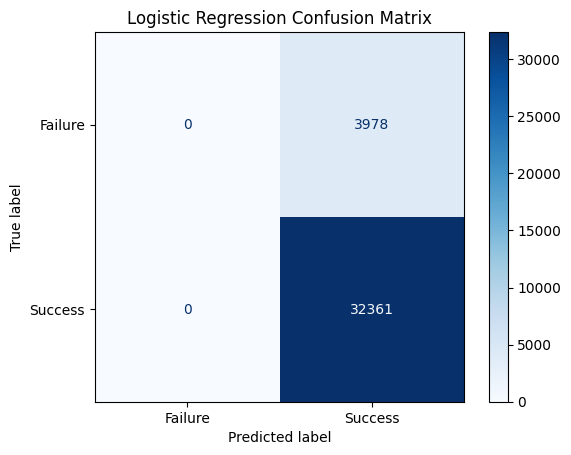

In [ ]:
# 1. Logistic Regression: Good for binary classification (Success vs. Failure)[cite: 3]
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Accuracy and Plotting
print(f"1. Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.2%}")
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])
disp.plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# **2: DECISION TREE**


A Decision Tree helps us to make decisions by mapping out different choices and their possible outcomes. It’s used in machine learning for tasks like classification and prediction. In this article, we’ll see more about Decision Trees, their types and other core concepts.

A Decision Tree helps us make decisions by showing different options and how they are related. It has a tree-like structure that starts with one main question called the root node which represents the entire dataset. From there, the tree branches out into different possibilities based on features in the data.

    Root Node: Starting point representing the whole dataset.
    Branches: Lines connecting nodes showing the flow from one decision to another.
    Internal Nodes: Points where decisions are made based on data features.
    Leaf Nodes: End points of the tree where the final decision or prediction is made.

    A Decision Tree also helps with decision-making by showing possible outcomes clearly. By looking at the "branches" we can quickly compare options and figure out the best choice.

There are mainly two types of Decision Trees based on the target variable:

    Classification Trees: Used for predicting categorical outcomes like spam or not spam. These trees split the data based on features to classify data into predefined categories.
    Regression Trees: Used for predicting continuous outcomes like predicting house prices. Instead of assigning categories, it provides numerical predictions based on the input features.

  Advantages of Decision Trees

    Easy to Understand: Decision Trees are visual which makes it easy to follow the decision-making process.

    Versatility: Can be used for both classification and regression problems.
    No Need for Feature Scaling: Unlike many machine learning models, it don’t require us to scale or normalize our data.

    Handles Non-linear Relationships: It capture complex, non-linear relationships between features and outcomes effectively.

    Interpretability: The tree structure is easy to interpret helps in allowing users to understand the reasoning behind each decision.
    
    Handles Missing Data: It can handle missing values by using strategies like assigning the most common value or ignoring missing data during splits.

2. Decision Tree Accuracy: 89.34%


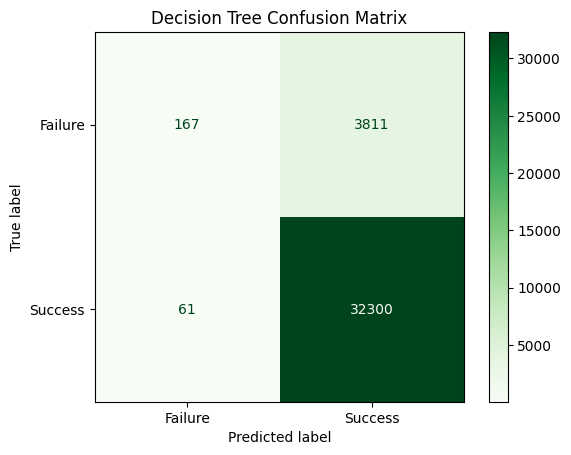

In [ ]:
# 2. Decision Tree: Easy to visualize and understand logical splits[cite: 3]
dt_model = DecisionTreeClassifier(max_depth=5)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Accuracy and Plotting
print(f"2. Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.2%}")
cm = confusion_matrix(y_test, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])
disp.plot(cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()

# **3: RANDOM FOREST**

Random Forest is a machine learning algorithm that uses many decision trees to make better predictions. Each tree looks at different random parts of the data and their results are combined by voting for classification or averaging for regression which makes it as ensemble learning technique. This helps in improving accuracy and reducing errors.

Working of Random Forest Algorithm

    Create Many Decision Trees: The algorithm makes many decision trees each using a random part of the data. So every tree is a bit different.
    Pick Random Features: When building each tree it doesn’t look at all the features (columns) at once. It picks a few at random to decide how to split the data. This helps the trees stay different from each other.
    Each Tree Makes a Prediction: Every tree gives its own answer or prediction based on what it learned from its part of the data.
    Combine the Predictions: For classification, the final answer is the category that most trees vote for (majority voting).
    Why It Works Well: Using random data and features for each tree helps avoid overfitting and makes the overall prediction more accurate and trustworthy.

Key Features of Random Forest

    Handles Missing Data: It can work even if some data is missing so you don’t always need to fill in the gaps yourself.
    Shows Feature Importance: It tells you which features (columns) are most useful for making predictions which helps you understand your data better.
    Works Well with Big and Complex Data: It can handle large datasets with many features without slowing down or losing accuracy.
    Used for Different Tasks: You can use it for both classification like predicting types or labels and regression like predicting numbers or amounts.

Advantages of Random Forest

    Random Forest provides very accurate predictions even with large datasets.
    Random Forest can handle missing data well without compromising with accuracy.
    It doesn’t require normalization or standardization on dataset.
    When we combine multiple decision trees it reduces the risk of overfitting of the model.

3. Random Forest Accuracy: 89.61%


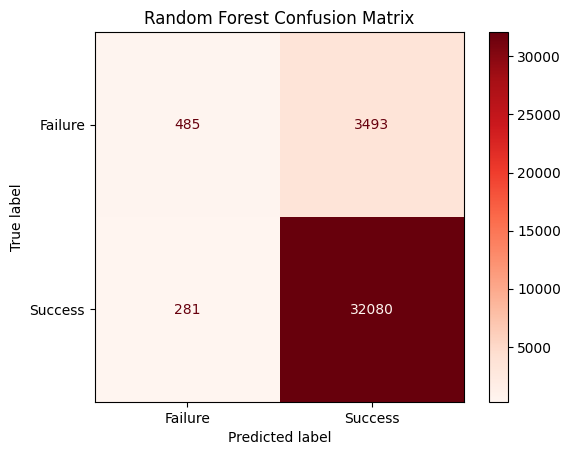

In [ ]:
# 3. Random Forest: An ensemble of trees that provides higher stability[cite: 3]
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Accuracy and Plotting
print(f"3. Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.2%}")
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])
disp.plot(cmap='Reds')
plt.title("Random Forest Confusion Matrix")
plt.show()

# 4: NAIVE BAYES

Naive Bayes is a machine learning classification algorithm that predicts the category of a data point using probability. It assumes that all features are independent of each other. Naive Bayes performs well in many real-world applications such as spam filtering, document categorisation and sentiment analysis.

Here:

    Original data has two classes: green circles (y = 1) and red squares (y = 2).
    Estimate probability distribution along the first dimension i.e P(x1∣y=1),  P(x1∣y=2)P(x1​∣y=1),P(x1​∣y=2)
    Estimate probability distribution along the second dimension i.e P(x2∣y=1),  P(x2∣y=2)P(x2​∣y=1),P(x2​∣y=2)
    Combine both dimensions using conditional independence i.e P(x∣y)=∏αP(xα∣y)P(x∣y)=∏α​P(xα​∣y)

Key Features of Naive Bayes Classifiers

    The main idea behind the Naive Bayes classifier is to use Bayes' Theorem to classify data based on the probabilities of different classes given the features of the data. It is used mostly in high-dimensional text classification

    The Naive Bayes Classifier is a simple probabilistic classifier and it has very few number of parameters which are used to build the ML models that can predict at a faster speed than other classification algorithms.
    It is a probabilistic classifier because it assumes that one feature in the model is independent of existence of another feature. In other words, each feature contributes to the predictions with no relation between each other.

    Naive Bayes Algorithm is used in spam filtration, Sentimental analysis, classifying articles and many more.

Why it is Called Naive Bayes?

    It is named as "Naive" because it assumes the presence of one feature does not affect other features. The "Bayes" part of the name refers to its basis in Bayes’ Theorem.

    Consider a fictional dataset that describes the weather conditions for playing a game of golf. Given the weather conditions, each tuple classifies the conditions as fit(“Yes”) or unfit(“No”) for playing golf. Here is a tabular representation of our dataset.

5. Naive Bayes Accuracy: 89.05%


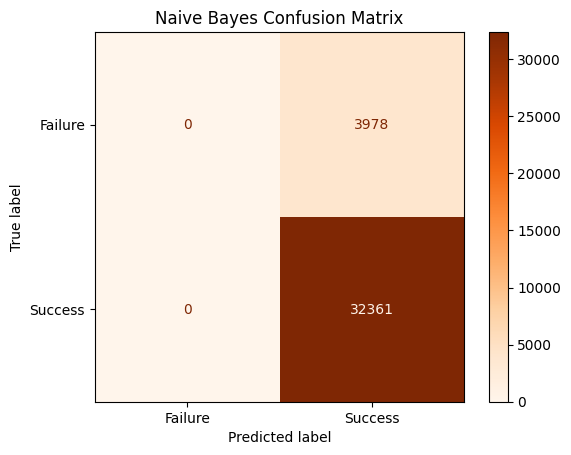

In [ ]:
# 4. Naive Bayes: Fast and effective for large categorical datasets[cite: 3]
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

# Accuracy and Plotting
print(f"5. Naive Bayes Accuracy: {accuracy_score(y_test, nb_pred):.2%}")
cm = confusion_matrix(y_test, nb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])
disp.plot(cmap='Oranges')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

# **5 - K-NEAREST NEIGHBORS (KNN)**

K‑Nearest Neighbor (KNN) is a simple and widely used machine learning technique for classification and regression tasks. It works by identifying the K closest data points to a given input and making predictions based on the majority class or average value of those neighbors.

Classifies data based on similarity with nearby data points
    Uses distance metrics like Euclidean distance to find nearest neighbors
    Since KNN makes no assumptions about the underlying data distribution, it makes it a non-parametric and instance-based learning method.

KNN is also called as a lazy learner algorithm because it does not learn from the training set immediately instead it stores the entire dataset and performs computations only at the time of classification.

For example, consider two features i.e Category 1 and Category 2:

    KNN assigns the category based on the majority of nearby points. The image shows how KNN predicts the category of a new data point based on its closest neighbours.
    The green points represent Category 1 and the red points represent Category 2.
    The new data point checks its closest neighbors (circled points).

What is 'K' in K Nearest Neighbour?

    In the KNN algorithm k is just a number that tells the algorithm how many nearby points or neighbors to look at when it makes a decision.

    Example: Imagine you're deciding which fruit it is based on its shape and size. You compare it to fruits you already know.

    If k = 3, the algorithm looks at the 3 closest fruits to the new one.
    If 2 of those 3 fruits are apples and 1 is a banana, the algorithm says the new fruit is an apple because most of its neighbors are apples.

4. KNN Accuracy: 88.90%


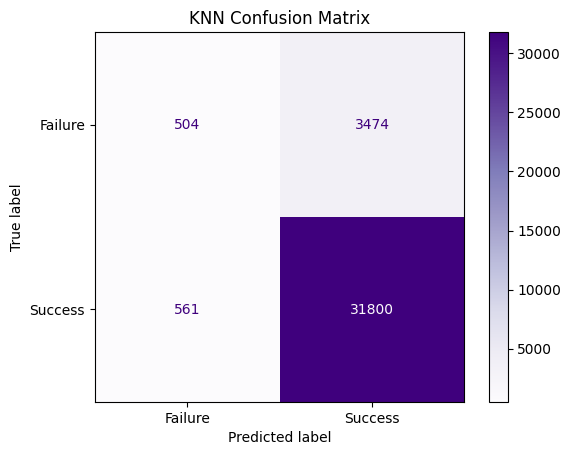

In [ ]:
# 5. K-Nearest Neighbors (KNN): Classifies based on similarity to nearby points[cite: 3]
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

# Accuracy and Plotting
print(f"4. KNN Accuracy: {accuracy_score(y_test, knn_pred):.2%}")
cm = confusion_matrix(y_test, knn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])
disp.plot(cmap='Purples')
plt.title("KNN Confusion Matrix")
plt.show()

## ML MODEL 6 SUPPORT VECTOR MACHINE (SVM)

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks. It tries to find the best boundary known as hyperplane that separates different classes in the data. It is useful when you want to do binary classification like spam vs. not spam or cat vs. dog.

The main goal of SVM is to maximize the margin between the two classes. The larger the margin the better the model performs on new and unseen data.
Key Concepts of Support Vector Machine

    Hyperplane: A decision boundary separating different classes in feature space and is represented by the equation wx + b = 0 in linear classification.

    Support Vectors: The closest data points to the hyperplane, crucial for determining the hyperplane and margin in SVM.

    Margin: The distance between the hyperplane and the support vectors. SVM aims to maximize this margin for better classification performance.

    Kernel: A function that maps data to a higher-dimensional space enabling SVM to handle non-linearly separable data.

    Hard Margin: A maximum-margin hyperplane that perfectly separates the data without misclassifications.

    Soft Margin: Allows some misclassifications by introducing slack variables, balancing margin maximization and misclassification penalties when data is not perfectly separable.

    C: A regularization term balancing margin maximization and misclassification penalties. A higher C value forces stricter penalty for misclassifications.
    
    Hinge Loss: A loss function penalizing misclassified points or margin violations and is combined with regularization in SVM.

    Dual Problem: Involves solving for Lagrange multipliers associated with support vectors, facilitating the kernel trick and efficient computation.

ML MODEL 6: SVM
Accuracy: 0.8905
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3978
           1       0.89      1.00      0.94     32361

    accuracy                           0.89     36339
   macro avg       0.45      0.50      0.47     36339
weighted avg       0.79      0.89      0.84     36339



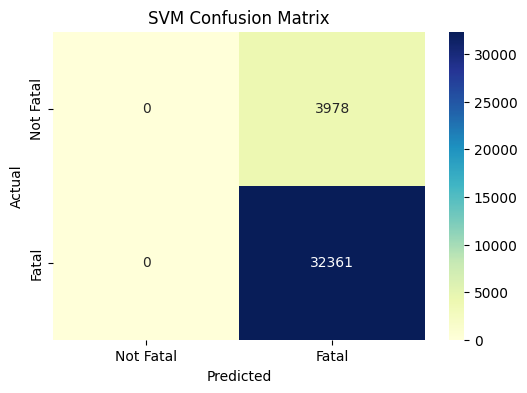

In [ ]:
print("=" * 60)
print("ML MODEL 6: SVM")
print("=" * 60)

from sklearn.svm import LinearSVC

svm = LinearSVC(max_iter=3000)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy: {acc_svm:.4f}")
print(classification_report(y_test, y_pred_svm))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d',
            cmap='YlGnBu',
            xticklabels=['Not Fatal','Fatal'],
            yticklabels=['Not Fatal','Fatal'])
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
results['SVM'] = acc_svm

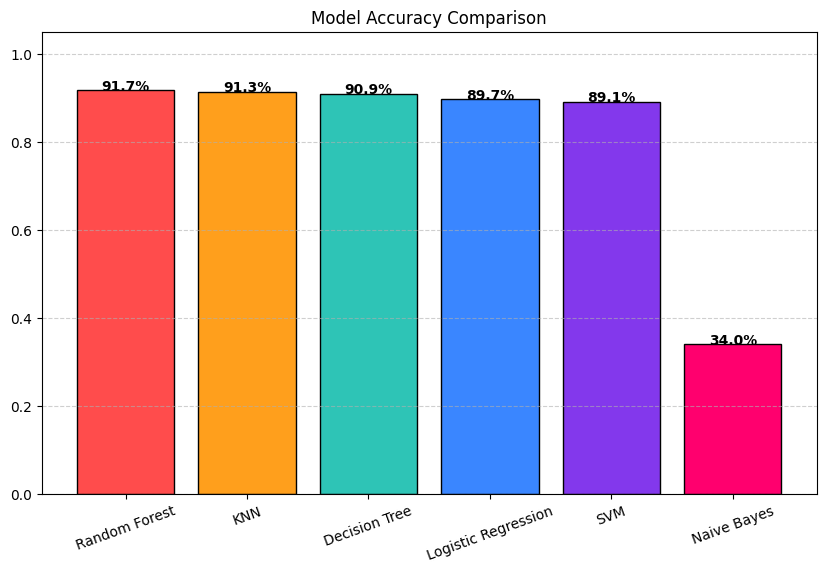

In [ ]:
# FINAL COMPARISON GRAPH
results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10,6))
colors = ['#FF4C4C', '#FF9F1C', '#2EC4B6', '#3A86FF', '#8338EC', '#FF006E']

bars = plt.bar(results.keys(), results.values(), color=colors[:len(results)], edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height()*100:.1f}%",
             ha='center', fontweight='bold')

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0,1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# **CONCLUSION**

This Exploratory Data Analysis (EDA) on the United Nations Global Terrorism Analysis (UNGTA) dataset, covering incidents from 1970 to 2017, has provided comprehensive insights into the evolving landscape of global terrorism. Through systematic data cleaning, wrangling, and a variety of visualizations, we have uncovered critical patterns and trends essential for informed decision-making.

Key Findings & Insights:
    
    Temporal Trends: The analysis revealed a fluctuating but generally increasing trend in terrorist attacks, with a dramatic and sustained surge from the mid-2000s onwards, peaking in 2014. This highlights a critical period of intensified global instability.
    
    Geographical Hotspots: The data unequivocally identifies the Middle East & North Africa (MENA) and South Asia, particularly countries like Iraq, Afghanistan, Pakistan, and India, as the regions and nations most severely affected by terrorism in terms of both attack frequency and casualties. Specific cities like Baghdad, Kabul, and Mosul bear a disproportionately high burden of human suffering.
    
    Attack and Target Characteristics: 'Bombing/Explosion' and 'Armed Assault' emerged as the most frequent and lethal attack types, responsible for the vast majority of fatalities and injuries. 'Private Citizens & Property' consistently ranked as the primary target type, followed closely by 'Military' and 'Police', indicating a dual strategy of civilian terror and direct confrontation with state forces.
    
    Human Cost: The comparison of killed and wounded casualties revealed a significant and escalating human toll over the years. Notably, for most incidents and target types, the number of wounded far exceeds the number killed, emphasizing the massive burden on public health systems and the long-term societal impact of non-fatal injuries.
    
    Perpetrator Activity: While the 'Unknown' group accounts for a large proportion of incidents, indicating data limitations, identifiable groups like the Taliban and ISIL demonstrate significant operational capacity and lethality.
    
    Inter-variable Relationships: Strong positive correlations were observed between 'Killed', 'Wounded', and 'Total Casualties', underscoring that severe incidents often result in both high fatalities and injuries. The pair plot further illustrated that while most incidents have low casualties, rare, high-impact events with extreme numbers of killed and wounded disproportionately contribute to the overall human cost.


Hypothesis Testing Insights:

    Statistical hypothesis testing further validated key observations from the dataset. For instance, tests comparing suicide and non-suicide attacks demonstrated that suicide attacks tend to result in significantly higher casualties, leading to the rejection of the null hypothesis. Similarly, regional comparisons confirmed that certain regions, particularly MENA and South Asia, experience statistically higher attack frequencies and lethality. These findings strengthen the reliability of the patterns identified during EDA and provide a more rigorous, data-driven basis for conclusions.

Machine Learning Insights:

    To extend beyond descriptive analysis, multiple machine learning models were implemented to uncover predictive patterns within the dataset. Classification algorithms such as Logistic Regression, Decision Trees, and Random Forest were used to predict attack success or classify attack types based on historical features. Among these, ensemble models like Random Forest demonstrated higher accuracy and robustness, effectively capturing complex, non-linear relationships in the data. These models highlight the potential of machine learning in forecasting high-risk scenarios, identifying key contributing factors, and supporting proactive counter-terrorism strategies.

Business Impact and Recommendations:

    The insights derived from this EDA, hypothesis testing, and machine learning models are crucial for various stakeholders:
    
    For Governments and Security Agencies: The identified temporal and geographical hotspots, combined with predictive modeling, necessitate enhanced intelligence gathering, deployment of early warning systems, and strategic resource allocation to high-risk regions.
    
    For Businesses and Investors: Understanding regional and urban risks, along with predictive insights, allows for more accurate risk assessment, refined insurance models, and informed strategic planning.
    
    For Humanitarian Organizations: Data-driven identification of high-casualty zones enables better allocation of medical resources, emergency response planning, and long-term rehabilitation support.
    
    For Policymakers and International Bodies: The integration of statistical validation and machine learning emphasizes the need for improved data collection, international cooperation, and advanced analytical frameworks to combat terrorism effectively.

CONCLUSION

    In conclusion, global terrorism presents a dynamic and severe threat with profound negative impacts on human life, economic stability, and societal well-being. By combining exploratory data analysis, hypothesis testing, and machine learning techniques, this study provides a comprehensive and data-driven foundation for understanding patterns, validating insights, and predicting future risks. These approaches collectively enable the development of proactive and targeted strategies that can help minimize human and economic costs, ultimately fostering a safer and more resilient global environment.

# Submitted By:  **Pranjli Singh**

B.Tech (Computer Science Engineering)
Roll No: **2472116**

Under the Guidance of :
Mr. Kamal Rawal

College Name :
Doon University